In [1]:
from pathlib import Path
import pandas as pd

# Define project and raw data paths
project = Path.cwd().parent
raw_data = project / "raw data"

# March data file
march_file = raw_data / "fhvhv_tripdata_2026-03.parquet"

print("Project:", project)
print("Raw data exists:", raw_data.exists())
print("March file exists:", march_file.exists())
print("March file:", march_file.name)

Project: /Users/dikshadev/    Projects/NYC_HV_FHV_ Analytics_2026
Raw data exists: True
March file exists: True
March file: fhvhv_tripdata_2026-03.parquet


In [2]:
# Load March 2026 HVFHV data

df = pd.read_parquet(march_file)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 22058358
Columns: 25


In [3]:
df.columns.tolist()

['hvfhs_license_num',
 'dispatching_base_num',
 'originating_base_num',
 'request_datetime',
 'on_scene_datetime',
 'pickup_datetime',
 'dropoff_datetime',
 'PULocationID',
 'DOLocationID',
 'trip_miles',
 'trip_time',
 'base_passenger_fare',
 'tolls',
 'bcf',
 'sales_tax',
 'congestion_surcharge',
 'airport_fee',
 'tips',
 'driver_pay',
 'shared_request_flag',
 'shared_match_flag',
 'access_a_ride_flag',
 'wav_request_flag',
 'wav_match_flag',
 'cbd_congestion_fee']

In [4]:
df.dtypes

hvfhs_license_num                  str
dispatching_base_num               str
originating_base_num               str
request_datetime        datetime64[us]
on_scene_datetime       datetime64[us]
pickup_datetime         datetime64[us]
dropoff_datetime        datetime64[us]
PULocationID                     int32
DOLocationID                     int32
trip_miles                     float64
trip_time                        int64
base_passenger_fare            float64
tolls                          float64
bcf                            float64
sales_tax                      float64
congestion_surcharge           float64
airport_fee                    float64
tips                           float64
driver_pay                     float64
shared_request_flag                str
shared_match_flag                  str
access_a_ride_flag                 str
wav_request_flag                   str
wav_match_flag                     str
cbd_congestion_fee             float64
dtype: object

In [5]:
# Check missing values in March data

missing_values = df.isnull().sum()

missing_values[missing_values > 0]

originating_base_num    6079600
dtype: int64

In [6]:
# Check for duplicate rows in March data

duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 1


In [7]:
# Check for unusual trip values in March data

print("Trip miles > 100:", (df["trip_miles"] > 100).sum())
print("Trip time > 4 hours:", (df["trip_time"] > 14400).sum())
print("Zero-mile trips:", (df["trip_miles"] == 0).sum())
print("Zero-time trips:", (df["trip_time"] == 0).sum())
print("Negative passenger fares:", (df["base_passenger_fare"] < 0).sum())
print("Negative driver pay:", (df["driver_pay"] < 0).sum())

Trip miles > 100: 1773
Trip time > 4 hours: 212
Zero-mile trips: 2557
Zero-time trips: 502
Negative passenger fares: 5669
Negative driver pay: 9


In [8]:
# Inspect examples of negative base passenger fares

df.loc[
    df["base_passenger_fare"] < 0,
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "tolls",
        "sales_tax",
        "congestion_surcharge",
        "airport_fee",
        "tips",
        "driver_pay"
    ]
].head(20)

,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,tolls,sales_tax,congestion_surcharge,airport_fee,tips,driver_pay
36932,2026-02-28 23:55:27,2026-03-01 00:08:17,2026-03-01 04:55:13,9.67,17215,-99.61,0.00,61.87,2.75,0.0,0.0,106.22
44382,2026-03-01 01:42:50,2026-03-01 01:45:56,2026-03-01 01:51:43,1.30,347,-0.16,0.00,0.87,0.00,0.0,0.0,5.82
70274,2026-03-01 01:52:49,2026-03-01 01:56:41,2026-03-01 01:57:46,0.14,64,-1.55,0.00,0.79,0.00,0.0,0.0,4.51
77706,2026-03-01 02:00:00,2026-03-01 02:02:12,2026-03-01 03:10:35,14.98,4103,-160.85,0.00,176.19,0.00,0.0,0.0,305.93
78522,2026-03-01 02:43:15,2026-03-01 02:47:41,2026-03-01 04:03:37,10.91,4556,-6.79,7.46,12.70,0.00,0.0,0.0,36.87
104274,2026-03-01 02:51:17,2026-03-01 03:08:29,2026-03-01 04:10:57,38.68,3748,-37.19,33.65,0.00,0.00,0.0,0.0,115.49
116465,2026-03-01 03:15:57,2026-03-01 03:21:44,2026-03-01 03:40:16,4.51,1112,-16.79,16.79,0.00,0.00,0.0,0.0,22.00
116703,2026-03-01 03:49:13,2026-03-01 03:54:30,2026-03-01 03:57:22,0.01,172,-2.42,0.00,1.89,0.00,0.0,0.0,11.26
118485,2026-03-01 03:35:46,2026-03-01 03:39:31,2026-03-01 03:43:21,0.76,230,-1.01,0.00,0.79,0.00,0.0,0.0,4.71
135832,2026-03-01 04:25:39,2026-03-01 04:30:27,2026-03-01 04:36:18,1.56,351,-3.11,0.00,0.00,0.00,2.5,0.0,12.45


In [9]:
# Summary statistics for negative base passenger fares

negative_fares = df.loc[
    df["base_passenger_fare"] < 0,
    "base_passenger_fare"
]

negative_fares.describe()

count    5669.000000
mean       -4.480736
std         8.581119
min      -284.060000
25%        -4.370000
50%        -1.960000
75%        -0.880000
max        -0.010000
Name: base_passenger_fare, dtype: float64

In [10]:
# Inspect zero-mile trips

zero_mile_trips = df.loc[
    df["trip_miles"] == 0,
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "driver_pay",
        "tips"
    ]
]

zero_mile_trips.head(20)

,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,driver_pay,tips
2886,2026-03-01 00:34:54,2026-03-01 00:41:02,2026-03-01 00:47:49,0.0,407,10.41,9.89,0.0
4535,2026-02-28 23:51:49,2026-03-01 00:00:20,2026-03-01 00:04:58,0.0,277,26.07,17.93,0.0
13351,2026-03-01 00:50:22,2026-03-01 00:56:32,2026-03-01 01:11:52,0.0,920,14.37,10.45,0.0
16888,2026-03-01 00:23:49,2026-03-01 00:28:48,2026-03-01 00:34:36,0.0,348,13.00,6.83,0.0
19202,2026-03-01 00:14:46,2026-03-01 00:21:16,2026-03-01 00:25:02,0.0,227,5.90,4.19,0.0
25934,2026-03-01 00:16:40,2026-03-01 00:54:48,2026-03-01 00:54:57,0.0,9,7.30,4.00,0.0
46465,2026-03-01 01:22:03,2026-03-01 01:29:03,2026-03-01 01:35:01,0.0,358,24.57,17.70,0.0
50656,2026-03-01 01:14:36,2026-03-01 01:16:03,2026-03-01 01:29:43,0.0,820,24.98,14.52,0.0
52675,2026-03-01 01:17:03,2026-03-01 01:19:01,2026-03-01 01:23:14,0.0,252,7.80,4.19,0.0
54276,2026-03-01 01:37:57,2026-03-01 01:41:42,2026-03-01 01:45:54,0.0,252,9.22,4.00,0.0


In [11]:
# Inspect zero-time trips

zero_time_trips = df.loc[
    df["trip_time"] == 0,
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "driver_pay",
        "tips"
    ]
]

zero_time_trips.head(20)

,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,driver_pay,tips
815250,2026-03-02 07:37:58,2026-03-02 07:41:37,2026-03-02 08:01:59.776,0.0,0,0.00,0.00,0.00
1162792,2026-03-02 18:39:27,2026-03-02 18:45:22,2026-03-02 18:52:37.920,0.0,0,0.00,0.17,0.00
1169296,2026-03-02 18:42:43,2026-03-02 18:47:31,2026-03-02 19:01:39.000,0.0,0,9.31,17.48,0.00
1280985,2026-03-02 21:25:57,2026-03-02 21:27:59,2026-03-02 21:33:32.880,0.0,0,0.00,0.00,0.00
1469255,2026-03-03 08:10:34,2026-03-03 08:13:14,2026-03-03 08:18:22.000,0.0,0,4.43,4.31,0.00
1496634,2026-03-03 08:17:50,2026-03-03 08:19:51,2026-03-03 08:30:03.303,0.0,0,0.00,0.00,0.00
1954232,2026-03-03 20:48:11,2026-03-03 20:56:40,2026-03-03 21:07:02.713,0.0,0,0.00,0.00,0.00
2413123,2026-03-04 14:37:52,2026-03-04 14:43:25,2026-03-04 14:47:41.000,0.0,0,5.83,4.23,0.00
2525192,2026-03-04 17:02:14,2026-03-04 17:25:42,2026-03-04 18:31:47.000,0.0,0,65.65,57.58,0.00
2797060,2026-03-05 05:17:41,2026-03-05 05:28:47,2026-03-05 06:08:17.000,0.0,0,36.80,43.75,0.00


In [12]:
# Compare recorded trip time with duration calculated from timestamps

zero_time_check = df.loc[
    df["trip_time"] == 0
].copy()

zero_time_check["calculated_trip_time"] = (
    zero_time_check["dropoff_datetime"] -
    zero_time_check["pickup_datetime"]
).dt.total_seconds()

print("Zero-time records:", len(zero_time_check))
print(
    "Zero-time records with positive timestamp duration:",
    (zero_time_check["calculated_trip_time"] > 0).sum()
)

zero_time_check[
    [
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "calculated_trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].head(20)

Zero-time records: 502
Zero-time records with positive timestamp duration: 502


,pickup_datetime,dropoff_datetime,trip_time,calculated_trip_time,trip_miles,base_passenger_fare,driver_pay
815250,2026-03-02 07:41:37,2026-03-02 08:01:59.776,0,1222.776,0.0,0.00,0.00
1162792,2026-03-02 18:45:22,2026-03-02 18:52:37.920,0,435.920,0.0,0.00,0.17
1169296,2026-03-02 18:47:31,2026-03-02 19:01:39.000,0,848.000,0.0,9.31,17.48
1280985,2026-03-02 21:27:59,2026-03-02 21:33:32.880,0,333.880,0.0,0.00,0.00
1469255,2026-03-03 08:13:14,2026-03-03 08:18:22.000,0,308.000,0.0,4.43,4.31
1496634,2026-03-03 08:19:51,2026-03-03 08:30:03.303,0,612.303,0.0,0.00,0.00
1954232,2026-03-03 20:56:40,2026-03-03 21:07:02.713,0,622.713,0.0,0.00,0.00
2413123,2026-03-04 14:43:25,2026-03-04 14:47:41.000,0,256.000,0.0,5.83,4.23
2525192,2026-03-04 17:25:42,2026-03-04 18:31:47.000,0,3965.000,0.0,65.65,57.58
2797060,2026-03-05 05:28:47,2026-03-05 06:08:17.000,0,2370.000,0.0,36.80,43.75


In [13]:
# Inspect negative driver pay records

negative_driver_pay = df.loc[
    df["driver_pay"] < 0,
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_miles",
        "trip_time",
        "base_passenger_fare",
        "tips",
        "driver_pay"
    ]
]

negative_driver_pay

,request_datetime,pickup_datetime,dropoff_datetime,trip_miles,trip_time,base_passenger_fare,tips,driver_pay
5221286,2026-03-08 03:32:49,2026-03-08 03:50:15,2026-03-08 04:18:10,7.20,1675,34.28,0.00,-3.62
8488589,2026-03-12 23:27:18,2026-03-12 23:28:50,2026-03-13 00:46:31,14.79,4662,-17.74,0.00,-2.10
9422796,2026-03-14 04:24:56,2026-03-14 04:36:27,2026-03-14 04:55:25,10.96,1137,23.46,0.00,-6.26
10910873,2026-03-16 05:39:58,2026-03-16 05:46:36,2026-03-16 07:35:54,18.75,6558,35.22,13.15,-2.82
15011827,2026-03-21 20:04:10,2026-03-21 20:17:38,2026-03-21 21:07:07,25.07,2969,145.26,0.00,-15.54
15058182,2026-03-21 20:59:54,2026-03-21 21:06:32,2026-03-21 21:55:39,18.10,2946,-32.66,0.00,-2.23
17664430,2026-03-25 19:17:58,2026-03-25 19:21:02,2026-03-25 21:08:58,42.36,6476,24.51,0.00,-1.76
17681930,2026-03-25 19:04:32,2026-03-25 19:07:56,2026-03-25 20:17:48,21.74,4192,-26.37,0.00,-5.60
21926957,2026-03-31 18:58:43,2026-03-31 19:00:26,2026-03-31 20:01:18,12.93,3652,-4.51,0.00,-3.97


In [14]:
# Check for invalid timestamp order

invalid_timestamps = df[
    df["dropoff_datetime"] < df["pickup_datetime"]
]

print("Trips with dropoff before pickup:", len(invalid_timestamps))

invalid_timestamps[
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].head(20)

Trips with dropoff before pickup: 0


,request_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay


In [15]:
# Check for invalid request-to-pickup timestamp order

invalid_request_pickup = df[
    df["pickup_datetime"] < df["request_datetime"]
]

print(
    "Trips with pickup before request:",
    len(invalid_request_pickup)
)

invalid_request_pickup[
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].head(20)

Trips with pickup before request: 294808


,request_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay
2337,2026-03-01 00:50:00,2026-03-01 00:32:24,2026-03-01 00:44:48,744,2.270,39.20,19.15
2777,2026-03-01 00:05:00,2026-03-01 00:00:24,2026-03-01 00:21:34,1269,5.310,31.42,28.60
2818,2026-03-01 00:50:00,2026-03-01 00:39:55,2026-03-01 01:08:07,1692,9.010,27.26,19.38
3570,2026-03-01 00:40:00,2026-03-01 00:34:20,2026-03-01 00:55:32,1272,3.410,37.65,35.72
3580,2026-03-01 00:22:00,2026-03-01 00:08:31,2026-03-01 00:36:06,1655,10.300,56.20,33.16
4331,2026-03-01 00:00:01,2026-03-01 00:00:00,2026-03-01 00:16:38,998,1.161,17.66,15.82
4366,2026-03-01 00:25:00,2026-03-01 00:12:00,2026-03-01 00:35:29,1408,3.620,21.18,20.50
4755,2026-03-01 00:28:54,2026-03-01 00:22:41,2026-03-01 00:46:35,1434,2.848,14.61,35.84
5301,2026-03-01 01:13:48,2026-03-01 00:58:18,2026-03-01 02:16:12,3181,17.440,89.10,81.80
6763,2026-03-01 00:25:00,2026-03-01 00:18:41,2026-03-01 00:50:09,1888,10.380,63.70,44.60


In [16]:
import numpy as np
# Measure the request-to-pickup timestamp difference

request_pickup_check = invalid_request_pickup.copy()

request_pickup_check["request_to_pickup_minutes"] = (
    request_pickup_check["pickup_datetime"]
    - request_pickup_check["request_datetime"]
).dt.total_seconds() / 60

print("Number of affected trips:", len(request_pickup_check))

print("\nTimestamp difference (minutes):")
print(request_pickup_check["request_to_pickup_minutes"].describe())

print("\nMost common ranges:")
print(
    pd.cut(
        request_pickup_check["request_to_pickup_minutes"],
        bins=[-np.inf, -30, -15, -5, -1, 0],
        labels=[
            "< -30 min",
            "-30 to -15 min",
            "-15 to -5 min",
            "-5 to -1 min",
            "0 min"
        ]
    ).value_counts().sort_index()
)

Number of affected trips: 294808

Timestamp difference (minutes):
count    294808.000000
mean         -7.307030
std           6.172945
min         -74.016667
25%         -10.683333
50%          -6.166667
75%          -2.283333
max          -0.016667
Name: request_to_pickup_minutes, dtype: float64

Most common ranges:
request_to_pickup_minutes
< -30 min           1598
-30 to -15 min     33657
-15 to -5 min     132383
-5 to -1 min       83008
0 min              44162
Name: count, dtype: int64


In [17]:
# Check the minute/second pattern of request timestamps

request_minute_pattern = pd.DataFrame({
    "minute": df["request_datetime"].dt.minute,
    "second": df["request_datetime"].dt.second
})

print("Unique minute values:")
print(sorted(request_minute_pattern["minute"].unique()))

print("\nUnique second values:")
print(sorted(request_minute_pattern["second"].unique()))

print("\nMost common request-minute values:")
print(request_minute_pattern["minute"].value_counts().sort_index())

Unique minute values:
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23), np.int32(24), np.int32(25), np.int32(26), np.int32(27), np.int32(28), np.int32(29), np.int32(30), np.int32(31), np.int32(32), np.int32(33), np.int32(34), np.int32(35), np.int32(36), np.int32(37), np.int32(38), np.int32(39), np.int32(40), np.int32(41), np.int32(42), np.int32(43), np.int32(44), np.int32(45), np.int32(46), np.int32(47), np.int32(48), np.int32(49), np.int32(50), np.int32(51), np.int32(52), np.int32(53), np.int32(54), np.int32(55), np.int32(56), np.int32(57), np.int32(58), np.int32(59)]

Unique second values:
[np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int

In [18]:
# Check the logical order of request, on-scene, and pickup timestamps

invalid_on_scene_order = df[
    (df["on_scene_datetime"] < df["request_datetime"]) |
    (df["on_scene_datetime"] > df["pickup_datetime"])
]

print(
    "Trips with invalid on-scene timestamp order:",
    len(invalid_on_scene_order)
)

invalid_on_scene_order[
    [
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles"
    ]
].head(20)

Trips with invalid on-scene timestamp order: 401323


,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles
1525,2026-02-28 23:49:00,2026-02-28 23:44:51,2026-03-01 00:18:51,2026-03-01 00:59:37,2446,31.460
2337,2026-03-01 00:50:00,2026-03-01 00:30:46,2026-03-01 00:32:24,2026-03-01 00:44:48,744,2.270
2777,2026-03-01 00:05:00,2026-02-28 23:56:24,2026-03-01 00:00:24,2026-03-01 00:21:34,1269,5.310
2818,2026-03-01 00:50:00,2026-03-01 00:39:11,2026-03-01 00:39:55,2026-03-01 01:08:07,1692,9.010
3570,2026-03-01 00:40:00,2026-03-01 00:29:56,2026-03-01 00:34:20,2026-03-01 00:55:32,1272,3.410
3580,2026-03-01 00:22:00,2026-03-01 00:07:31,2026-03-01 00:08:31,2026-03-01 00:36:06,1655,10.300
4250,2026-03-01 00:00:00,2026-02-28 23:49:27,2026-03-01 00:03:39,2026-03-01 00:46:31,2572,23.830
4331,2026-03-01 00:00:01,2026-02-28 23:55:42,2026-03-01 00:00:00,2026-03-01 00:16:38,998,1.161
4366,2026-03-01 00:25:00,2026-03-01 00:11:30,2026-03-01 00:12:00,2026-03-01 00:35:29,1408,3.620
4755,2026-03-01 00:28:54,2026-03-01 00:21:41,2026-03-01 00:22:41,2026-03-01 00:46:35,1434,2.848


In [19]:
# Separate the two types of on-scene timestamp inconsistencies

on_scene_before_request = df[
    df["on_scene_datetime"] < df["request_datetime"]
]

on_scene_after_pickup = df[
    df["on_scene_datetime"] > df["pickup_datetime"]
]

print(
    "On-scene before request:",
    len(on_scene_before_request)
)

print(
    "On-scene after pickup:",
    len(on_scene_after_pickup)
)

print(
    "Both conditions:",
    len(
        df[
            (df["on_scene_datetime"] < df["request_datetime"]) &
            (df["on_scene_datetime"] > df["pickup_datetime"])
        ]
    )
)

On-scene before request: 400904
On-scene after pickup: 631
Both conditions: 212


In [20]:
# Inspect trips where on-scene time is after pickup time

on_scene_after_pickup[
    [
        "request_datetime",
        "on_scene_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].head(20)

,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay
5301,2026-03-01 01:13:48,2026-03-01 01:18:11,2026-03-01 00:58:18,2026-03-01 02:16:12,3181,17.44,89.10,81.80
11535,2026-03-01 00:27:19,2026-03-01 00:28:48,2026-03-01 00:19:26,2026-03-01 01:30:37,3589,30.57,133.90,95.88
25785,2026-03-01 00:27:09,2026-03-01 00:29:34,2026-03-01 00:07:10,2026-03-01 01:18:21,2807,7.40,56.04,43.14
28995,2026-03-01 00:56:13,2026-03-01 00:58:34,2026-03-01 00:52:55,2026-03-01 01:23:08,1354,3.21,29.04,19.25
45280,2026-03-01 00:55:24,2026-03-01 01:11:03,2026-03-01 01:00:03,2026-03-01 01:42:59,1796,7.07,40.10,29.21
49684,2026-03-01 01:47:27,2026-03-01 01:52:52,2026-03-01 01:49:18,2026-03-01 02:15:07,1215,2.67,16.56,17.28
148520,2026-03-01 05:36:17,2026-03-01 05:45:20,2026-03-01 05:41:40,2026-03-01 06:28:43,2823,27.30,101.58,75.59
186378,2026-03-01 08:52:40,2026-03-01 08:57:48,2026-03-01 08:31:17,2026-03-01 09:50:16,3000,8.20,30.27,48.02
308210,2026-03-01 12:44:27,2026-03-01 12:51:10,2026-03-01 12:38:01,2026-03-01 13:10:48,1057,6.47,42.71,23.58
504279,2026-03-01 17:49:09,2026-03-01 17:53:03,2026-03-01 17:43:24,2026-03-01 18:42:31,2845,23.48,95.54,68.02


In [21]:
# Measure how far the on-scene timestamp occurs after pickup

on_scene_pickup_check = on_scene_after_pickup.copy()

on_scene_pickup_check["on_scene_after_pickup_minutes"] = (
    on_scene_pickup_check["on_scene_datetime"]
    - on_scene_pickup_check["pickup_datetime"]
).dt.total_seconds() / 60

print("Affected trips:", len(on_scene_pickup_check))

print("\nTime difference (minutes):")
print(
    on_scene_pickup_check["on_scene_after_pickup_minutes"].describe()
)

print("\nLargest mismatches:")
print(
    on_scene_pickup_check[
        [
            "on_scene_after_pickup_minutes",
            "on_scene_datetime",
            "pickup_datetime",
            "dropoff_datetime",
            "trip_time"
        ]
    ]
    .sort_values("on_scene_after_pickup_minutes", ascending=False)
    .head(10)
)

Affected trips: 631

Time difference (minutes):
count    631.000000
mean       7.685790
std        7.682996
min        0.016667
25%        1.158333
50%        6.050000
75%       11.508333
max       52.616667
Name: on_scene_after_pickup_minutes, dtype: float64

Largest mismatches:
          on_scene_after_pickup_minutes   on_scene_datetime  \
7347700                       52.616667 2026-03-11 14:32:56   
18130828                      36.400000 2026-03-26 14:34:52   
12038018                      36.316667 2026-03-17 20:34:00   
14377552                      35.783333 2026-03-21 00:21:02   
912235                        35.533333 2026-03-02 10:46:43   
18082827                      33.416667 2026-03-26 12:29:53   
11895636                      33.233333 2026-03-17 16:06:35   
14429750                      32.416667 2026-03-21 01:24:48   
14608514                      29.150000 2026-03-21 09:39:18   
13424316                      29.083333 2026-03-19 17:41:23   

             pickup_datet

In [22]:
# Inspect exact duplicate rows

duplicate_rows = df[df.duplicated(keep=False)].copy()

print("Total rows involved in exact duplicates:", len(duplicate_rows))

duplicate_rows

Total rows involved in exact duplicates: 2


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
13785639,HV0003,B03404,B03404,2026-03-20 07:06:59,2026-03-20 07:07:38,2026-03-20 07:07:49,2026-03-20 07:20:33,4,162,2.43,...,0.75,0.0,0.0,8.66,Y,Y,N,N,N,1.5
13785640,HV0003,B03404,B03404,2026-03-20 07:06:59,2026-03-20 07:07:38,2026-03-20 07:07:49,2026-03-20 07:20:33,4,162,2.43,...,0.75,0.0,0.0,8.66,Y,Y,N,N,N,1.5


In [23]:
# Create a working copy and remove exact duplicate rows

df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Rows after removing duplicates:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 22058358
Rows after removing duplicates: 22058357
Rows removed: 1


In [24]:
# Check pickup and dropoff location IDs

print("Pickup Location ID range:")
print("Minimum:", df_clean["PULocationID"].min())
print("Maximum:", df_clean["PULocationID"].max())

print("\nDropoff Location ID range:")
print("Minimum:", df_clean["DOLocationID"].min())
print("Maximum:", df_clean["DOLocationID"].max())

print("\nInvalid pickup IDs (<= 0):",
      (df_clean["PULocationID"] <= 0).sum())

print("Invalid dropoff IDs (<= 0):",
      (df_clean["DOLocationID"] <= 0).sum())

Pickup Location ID range:
Minimum: 2
Maximum: 265

Dropoff Location ID range:
Minimum: 1
Maximum: 265

Invalid pickup IDs (<= 0): 0
Invalid dropoff IDs (<= 0): 0


In [25]:
# Check categorical flag values

flag_columns = [
    "shared_request_flag",
    "shared_match_flag",
    "access_a_ride_flag",
    "wav_request_flag",
    "wav_match_flag"
]

for col in flag_columns:
    print(f"\n{col}:")
    print(df_clean[col].value_counts(dropna=False))


shared_request_flag:
shared_request_flag
N    21726893
Y      331464
Name: count, dtype: int64

shared_match_flag:
shared_match_flag
N    21876413
Y      181944
Name: count, dtype: int64

access_a_ride_flag:
access_a_ride_flag
N    22036940
Y       21417
Name: count, dtype: int64

wav_request_flag:
wav_request_flag
N    21994002
Y       64355
Name: count, dtype: int64

wav_match_flag:
wav_match_flag
N    19966482
Y     2091875
Name: count, dtype: int64


In [26]:
# Check HVFHS license/provider codes

print("Unique HVFHS license numbers:")
print(df_clean["hvfhs_license_num"].value_counts(dropna=False))

print("\nUnique dispatching bases:",
      df_clean["dispatching_base_num"].nunique())

print("Unique originating bases:",
      df_clean["originating_base_num"].nunique())

print("\nMissing dispatching base:",
      df_clean["dispatching_base_num"].isna().sum())

print("Missing originating base:",
      df_clean["originating_base_num"].isna().sum())

Unique HVFHS license numbers:
hvfhs_license_num
HV0003    15956174
HV0005     6102183
Name: count, dtype: int64

Unique dispatching bases: 2
Unique originating bases: 5

Missing dispatching base: 0
Missing originating base: 6079600


In [27]:
# Check negative values across monetary columns

monetary_columns = [
    "base_passenger_fare",
    "tolls",
    "bcf",
    "sales_tax",
    "congestion_surcharge",
    "airport_fee",
    "tips",
    "driver_pay",
    "cbd_congestion_fee"
]

for col in monetary_columns:
    negative_count = (df_clean[col] < 0).sum()
    print(f"{col}: {negative_count:,} negative values")

base_passenger_fare: 5,669 negative values
tolls: 0 negative values
bcf: 0 negative values
sales_tax: 0 negative values
congestion_surcharge: 0 negative values
airport_fee: 0 negative values
tips: 0 negative values
driver_pay: 9 negative values
cbd_congestion_fee: 0 negative values


In [28]:
# Check trips with zero values across major financial fields

zero_financial_trips = df_clean[
    (df_clean["base_passenger_fare"] == 0) &
    (df_clean["driver_pay"] == 0) &
    (df_clean["tips"] == 0)
]

print("Trips with zero base fare, driver pay, and tips:",
      len(zero_financial_trips))

zero_financial_trips[
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "tips",
        "driver_pay"
    ]
].head(20)

Trips with zero base fare, driver pay, and tips: 253


,request_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,tips,driver_pay
92794,2026-03-01 02:38:50,2026-03-01 02:47:15,2026-03-01 03:26:12.000,2336,19.23,0.0,0.0,0.0
126664,2026-03-01 04:46:02,2026-03-01 04:48:32,2026-03-01 04:52:07.000,216,0.00,0.0,0.0,0.0
259662,2026-03-01 10:25:14,2026-03-01 10:36:32,2026-03-01 10:40:28.000,236,0.71,0.0,0.0,0.0
631928,2026-03-01 21:23:24,2026-03-01 21:28:27,2026-03-01 21:29:21.000,54,0.26,0.0,0.0,0.0
657598,2026-03-01 22:16:17,2026-03-01 22:27:15,2026-03-01 22:33:50.000,396,0.98,0.0,0.0,0.0
815250,2026-03-02 07:37:58,2026-03-02 07:41:37,2026-03-02 08:01:59.776,0,0.00,0.0,0.0,0.0
920530,2026-03-02 10:35:23,2026-03-02 10:39:02,2026-03-02 10:41:33.000,151,0.25,0.0,0.0,0.0
947542,2026-03-02 11:03:56,2026-03-02 11:04:39,2026-03-02 11:05:27.000,48,0.02,0.0,0.0,0.0
948212,2026-03-02 11:20:33,2026-03-02 11:26:14,2026-03-02 11:39:45.000,811,0.23,0.0,0.0,0.0
965263,2026-03-02 11:57:41,2026-03-02 12:01:53,2026-03-02 12:25:19.000,1406,9.06,0.0,0.0,0.0


In [29]:
# Compare recorded trip_time with timestamp-derived trip duration

calculated_trip_time = (
    df_clean["dropoff_datetime"] - df_clean["pickup_datetime"]
).dt.total_seconds()

trip_time_difference = (
    df_clean["trip_time"] - calculated_trip_time
)

print("Recorded trip time vs timestamp-derived duration:")

print("\nDifference in seconds:")
print(trip_time_difference.describe())

print(
    "\nTrips where recorded and calculated duration differ:",
    (trip_time_difference != 0).sum()
)

print(
    "Trips where difference is greater than 1 second:",
    (trip_time_difference.abs() > 1).sum()
)

Recorded trip time vs timestamp-derived duration:

Difference in seconds:
count    2.205836e+07
mean    -1.524680e+00
std      7.396620e+01
min     -5.127000e+03
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      3.000000e+00
dtype: float64

Trips where recorded and calculated duration differ: 4024922
Trips where difference is greater than 1 second: 11754


In [30]:
# Inspect the largest differences between recorded and calculated trip duration

duration_mismatch = df_clean[
    trip_time_difference.abs() > 1
].copy()

duration_mismatch["calculated_trip_time"] = (
    df_clean.loc[
        duration_mismatch.index,
        "dropoff_datetime"
    ]
    - df_clean.loc[
        duration_mismatch.index,
        "pickup_datetime"
    ]
).dt.total_seconds()

duration_mismatch["duration_difference"] = (
    duration_mismatch["trip_time"]
    - duration_mismatch["calculated_trip_time"]
)

duration_mismatch[
    [
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "calculated_trip_time",
        "duration_difference",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].sort_values(
    "duration_difference"
).head(20)

,pickup_datetime,dropoff_datetime,trip_time,calculated_trip_time,duration_difference,trip_miles,base_passenger_fare,driver_pay
5876822,2026-03-09 06:40:28,2026-03-09 08:05:55,0,5127.0,-5127.0,0.00,159.83,147.13
5870791,2026-03-09 06:44:08,2026-03-09 08:04:22,0,4814.0,-4814.0,0.00,66.99,80.17
2377694,2026-03-04 13:53:09,2026-03-04 15:43:39,2473,6630.0,-4157.0,18.63,77.75,56.47
5868221,2026-03-09 06:57:55,2026-03-09 08:05:20,0,4045.0,-4045.0,0.00,119.29,92.62
2525192,2026-03-04 17:25:42,2026-03-04 18:31:47,0,3965.0,-3965.0,0.00,65.65,57.58
17880123,2026-03-26 04:52:20,2026-03-26 06:01:39,246,4159.0,-3913.0,9.00,98.56,51.62
5189746,2026-03-08 01:54:29,2026-03-08 03:40:09,2469,6340.0,-3871.0,13.70,45.44,45.56
5171311,2026-03-08 01:42:42,2026-03-08 03:14:08,1885,5486.0,-3601.0,17.35,40.75,43.66
5161033,2026-03-08 01:55:30,2026-03-08 03:00:42,311,3912.0,-3601.0,0.69,7.98,4.42
5186910,2026-03-08 01:55:41,2026-03-08 03:04:36,534,4135.0,-3601.0,3.87,34.75,17.43


In [31]:
# Classify large duration differences

large_duration_diff = trip_time_difference.abs() > 1

print("Differences > 1 second:", large_duration_diff.sum())

print(
    "\nDifferences approximately 1 hour (between 3590 and 3610 sec):",
    (
        trip_time_difference.abs().between(3590, 3610)
    ).sum()
)

print(
    "\nDifferences greater than 1 hour:",
    (
        trip_time_difference.abs() > 3600
    ).sum()
)

print(
    "\nDifferences greater than 5 minutes but not approximately 1 hour:",
    (
        (trip_time_difference.abs() > 300) &
        (~trip_time_difference.abs().between(3590, 3610))
    ).sum()
)

Differences > 1 second: 11754

Differences approximately 1 hour (between 3590 and 3610 sec): 9207

Differences greater than 1 hour: 738

Differences greater than 5 minutes but not approximately 1 hour: 916


In [32]:
# Inspect extreme trip distances

extreme_distance = df_clean[
    df_clean["trip_miles"] > 100
]["trip_miles"]

print("Trips with trip_miles > 100:", len(extreme_distance))

print("\nDistance statistics:")
print(extreme_distance.describe())

print("\nTop 20 longest trips:")
print(
    df_clean[
        [
            "pickup_datetime",
            "dropoff_datetime",
            "trip_time",
            "trip_miles",
            "base_passenger_fare",
            "driver_pay"
        ]
    ]
    .sort_values("trip_miles", ascending=False)
    .head(20)
)

Trips with trip_miles > 100: 1773

Distance statistics:
count    1773.000000
mean      131.532288
std        68.620989
min       100.010000
25%       106.900000
50%       115.020000
75%       131.380000
max      1644.540000
Name: trip_miles, dtype: float64

Top 20 longest trips:
             pickup_datetime    dropoff_datetime  trip_time  trip_miles  \
11493896 2026-03-16 22:28:04 2026-03-16 23:04:39       2195    1644.540   
11485634 2026-03-16 22:59:46 2026-03-16 23:20:46       1261    1626.380   
22016132 2026-03-31 22:29:28 2026-03-31 22:48:45       1157     961.340   
8402245  2026-03-12 21:33:55 2026-03-12 22:04:39       1844     771.960   
12071718 2026-03-17 20:24:12 2026-03-18 05:31:29      32837     510.550   
4765948  2026-03-07 16:18:45 2026-03-08 04:14:51      39367     506.580   
21445621 2026-03-30 23:21:33 2026-03-31 08:10:38      31745     490.940   
247242   2026-03-01 10:47:33 2026-03-01 20:26:30      34737     405.736   
5815740  2026-03-09 01:18:19 2026-03-09 07:58

In [33]:
# Calculate implied average speed for extreme-distance trips

extreme_speed_check = df_clean[
    df_clean["trip_miles"] > 100
][
    [
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].copy()

extreme_speed_check["speed_mph"] = (
    extreme_speed_check["trip_miles"]
    / (extreme_speed_check["trip_time"] / 3600)
)

print("Implied speed statistics for trips >100 miles:")
print(extreme_speed_check["speed_mph"].describe())

print("\nTop 20 implied speeds:")
print(
    extreme_speed_check
    .sort_values("speed_mph", ascending=False)
    .head(20)
)

Implied speed statistics for trips >100 miles:
count    1773.000000
mean       55.518291
std       148.211369
min        18.128633
25%        44.421635
50%        49.672157
75%        54.182101
max      4643.114988
Name: speed_mph, dtype: float64

Top 20 implied speeds:
             pickup_datetime    dropoff_datetime  trip_time  trip_miles  \
11485634 2026-03-16 22:59:46 2026-03-16 23:20:46       1261    1626.380   
22016132 2026-03-31 22:29:28 2026-03-31 22:48:45       1157     961.340   
11493896 2026-03-16 22:28:04 2026-03-16 23:04:39       2195    1644.540   
8402245  2026-03-12 21:33:55 2026-03-12 22:04:39       1844     771.960   
962742   2026-03-02 12:58:50 2026-03-02 13:55:27       3397     101.720   
8439542  2026-03-12 22:38:26 2026-03-13 00:07:20       5334     105.524   
13259088 2026-03-19 13:50:53 2026-03-19 17:31:34      13241     250.996   
620940   2026-03-01 21:24:14 2026-03-02 00:29:29      11115     205.700   
7706550  2026-03-11 23:22:46 2026-03-12 02:43:49      

In [34]:
# Quantify implausibly high implied speeds

speed_thresholds = [80, 100, 120, 150, 200, 300]

print("Trips >100 miles by implied speed:\n")

for threshold in speed_thresholds:
    count = (extreme_speed_check["speed_mph"] > threshold).sum()
    print(f"Speed > {threshold} mph: {count:,}")

Trips >100 miles by implied speed:

Speed > 80 mph: 5
Speed > 100 mph: 5
Speed > 120 mph: 4
Speed > 150 mph: 4
Speed > 200 mph: 4
Speed > 300 mph: 4


In [35]:
# Inspect trips with implied speed above 80 mph

extreme_speed_check[
    extreme_speed_check["speed_mph"] > 80
].sort_values(
    "speed_mph",
    ascending=False
)

,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay,speed_mph
11485634,2026-03-16 22:59:46,2026-03-16 23:20:46,1261,1626.38,75.82,63.18,4643.114988
22016132,2026-03-31 22:29:28,2026-03-31 22:48:45,1157,961.34,44.73,38.03,2991.204840
11493896,2026-03-16 22:28:04,2026-03-16 23:04:39,2195,1644.54,118.48,94.49,2697.195444
8402245,2026-03-12 21:33:55,2026-03-12 22:04:39,1844,771.96,73.61,62.83,1507.080260
962742,2026-03-02 12:58:50,2026-03-02 13:55:27,3397,101.72,109.46,95.78,107.798646


In [37]:
# Inspect provider and location details for extreme-speed trips

extreme_speed_index = extreme_speed_check.index[
    extreme_speed_check["speed_mph"] > 80
]

extreme_speed_records = df_clean.loc[
    extreme_speed_index,
    [
        "hvfhs_license_num",
        "dispatching_base_num",
        "originating_base_num",
        "PULocationID",
        "DOLocationID",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].copy()

extreme_speed_records["speed_mph"] = extreme_speed_check.loc[
    extreme_speed_index,
    "speed_mph"
]

extreme_speed_records.sort_values(
    "speed_mph",
    ascending=False
)

,hvfhs_license_num,dispatching_base_num,originating_base_num,PULocationID,DOLocationID,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay,speed_mph
11485634,HV0003,B03404,B03404,138,161,2026-03-16 22:59:46,2026-03-16 23:20:46,1261,1626.38,75.82,63.18,4643.114988
22016132,HV0003,B03404,B03404,138,140,2026-03-31 22:29:28,2026-03-31 22:48:45,1157,961.34,44.73,38.03,2991.204840
11493896,HV0003,B03404,B03404,138,265,2026-03-16 22:28:04,2026-03-16 23:04:39,2195,1644.54,118.48,94.49,2697.195444
8402245,HV0003,B03404,B03404,138,230,2026-03-12 21:33:55,2026-03-12 22:04:39,1844,771.96,73.61,62.83,1507.080260
962742,HV0003,B03404,B03404,265,265,2026-03-02 12:58:50,2026-03-02 13:55:27,3397,101.72,109.46,95.78,107.798646


In [38]:
# Inspect the extreme-speed records in detail

extreme_speed_records[
    [
        "hvfhs_license_num",
        "dispatching_base_num",
        "originating_base_num",
        "PULocationID",
        "DOLocationID",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay",
        "speed_mph"
    ]
]

,hvfhs_license_num,dispatching_base_num,originating_base_num,PULocationID,DOLocationID,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay,speed_mph
962742,HV0003,B03404,B03404,265,265,2026-03-02 12:58:50,2026-03-02 13:55:27,3397,101.72,109.46,95.78,107.798646
8402245,HV0003,B03404,B03404,138,230,2026-03-12 21:33:55,2026-03-12 22:04:39,1844,771.96,73.61,62.83,1507.080260
11485634,HV0003,B03404,B03404,138,161,2026-03-16 22:59:46,2026-03-16 23:20:46,1261,1626.38,75.82,63.18,4643.114988
11493896,HV0003,B03404,B03404,138,265,2026-03-16 22:28:04,2026-03-16 23:04:39,2195,1644.54,118.48,94.49,2697.195444
22016132,HV0003,B03404,B03404,138,140,2026-03-31 22:29:28,2026-03-31 22:48:45,1157,961.34,44.73,38.03,2991.204840


In [39]:
# Inspect the longest recorded trip durations

long_duration_trips = df_clean.loc[
    df_clean["trip_time"] > 14400,
    [
        "hvfhs_license_num",
        "dispatching_base_num",
        "originating_base_num",
        "PULocationID",
        "DOLocationID",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].copy()

print("Trips with trip_time > 4 hours:", len(long_duration_trips))

long_duration_trips = long_duration_trips.sort_values(
    "trip_time",
    ascending=False
)

long_duration_trips.head(20)

Trips with trip_time > 4 hours: 212


,hvfhs_license_num,dispatching_base_num,originating_base_num,PULocationID,DOLocationID,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay
4765948,HV0003,B03404,B03404,78,78,2026-03-07 16:18:45,2026-03-08 04:14:51,39367,506.580,-284.06,1520.34
21923974,HV0003,B03404,B03404,152,168,2026-03-31 19:00:25,2026-04-01 05:29:51,37766,38.290,652.25,493.12
11958044,HV0003,B03404,B03404,217,265,2026-03-17 17:10:54,2026-03-18 03:14:00,36186,31.470,-47.54,161.57
17784593,HV0005,B03406,NaN,144,135,2026-03-25 22:56:44,2026-03-26 08:38:22,34898,11.435,548.96,410.77
247242,HV0005,B03406,NaN,161,162,2026-03-01 10:47:33,2026-03-01 20:26:30,34737,405.736,963.42,914.83
12110078,HV0005,B03406,NaN,126,51,2026-03-17 21:54:50,2026-03-18 07:27:15,34345,17.029,550.19,411.67
12071718,HV0003,B03404,B03404,78,78,2026-03-17 20:24:12,2026-03-18 05:31:29,32837,510.550,1232.04,1291.62
3783660,HV0005,B03406,NaN,66,82,2026-03-06 11:36:32,2026-03-06 20:39:18,32566,8.192,508.00,382.28
21445621,HV0003,B03404,B03404,78,78,2026-03-30 23:21:33,2026-03-31 08:10:38,31745,490.940,1007.43,1240.96
4609977,HV0005,B03406,NaN,225,72,2026-03-07 12:51:43,2026-03-07 21:33:29,31306,6.775,486.45,364.02


In [40]:
# Compare recorded and timestamp-derived duration for trips longer than 4 hours

long_duration_check = long_duration_trips.copy()

long_duration_check["calculated_trip_time"] = (
    long_duration_check["dropoff_datetime"]
    - long_duration_check["pickup_datetime"]
).dt.total_seconds()

long_duration_check["duration_difference"] = (
    long_duration_check["trip_time"]
    - long_duration_check["calculated_trip_time"]
)

print("Recorded vs timestamp-derived duration for >4-hour trips:")
print(
    long_duration_check["duration_difference"]
    .describe()
)

print("\nDifferences approximately 1 hour:")
print(
    long_duration_check["duration_difference"]
    .abs()
    .between(3590, 3610)
    .sum()
)

print("\nDifferences greater than 1 hour:")
print(
    (long_duration_check["duration_difference"].abs() > 3610).sum()
)

print("\nLargest duration differences:")
long_duration_check.sort_values(
    "duration_difference",
    key=lambda x: x.abs(),
    ascending=False
)[
    [
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "calculated_trip_time",
        "duration_difference",
        "trip_miles"
    ]
].head(20)

Recorded vs timestamp-derived duration for >4-hour trips:
count     212.000000
mean      -33.957547
std       348.785113
min     -3600.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: duration_difference, dtype: float64

Differences approximately 1 hour:
2

Differences greater than 1 hour:
0

Largest duration differences:


,pickup_datetime,dropoff_datetime,trip_time,calculated_trip_time,duration_difference,trip_miles
4984878,2026-03-07 21:51:59,2026-03-08 05:25:30,23611,27211.0,-3600.0,76.202
4765948,2026-03-07 16:18:45,2026-03-08 04:14:51,39367,42966.0,-3599.0,506.580
13882781,2026-03-20 10:40:22,2026-03-20 15:26:23,17160,17161.0,-1.0,214.440
6661469,2026-03-10 12:01:31,2026-03-10 17:30:56,19766,19765.0,1.0,74.420
21471460,2026-03-31 01:22:50,2026-03-31 06:44:52,19323,19322.0,1.0,30.460
8848323,2026-03-13 13:32:20,2026-03-13 17:40:29,14888,14889.0,-1.0,67.710
7770683,2026-03-12 03:58:18,2026-03-12 09:08:37,18620,18619.0,1.0,253.100
6071888,2026-03-09 12:29:06,2026-03-09 17:35:54,18409,18408.0,1.0,236.020
21118757,2026-03-30 12:30:03,2026-03-30 16:55:17,15913,15914.0,-1.0,212.470
12467240,2026-03-18 11:15:38,2026-03-18 15:26:44,15065,15066.0,-1.0,204.270


In [41]:
# Inspect the two long-duration records with a 1-hour discrepancy

long_duration_check.loc[
    long_duration_check["duration_difference"].abs().between(3590, 3610),
    [
        "hvfhs_license_num",
        "dispatching_base_num",
        "originating_base_num",
        "PULocationID",
        "DOLocationID",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "calculated_trip_time",
        "duration_difference",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
]

,hvfhs_license_num,dispatching_base_num,originating_base_num,PULocationID,DOLocationID,pickup_datetime,dropoff_datetime,trip_time,calculated_trip_time,duration_difference,trip_miles,base_passenger_fare,driver_pay
4765948,HV0003,B03404,B03404,78,78,2026-03-07 16:18:45,2026-03-08 04:14:51,39367,42966.0,-3599.0,506.580,-284.06,1520.34
4984878,HV0005,B03406,NaN,135,188,2026-03-07 21:51:59,2026-03-08 05:25:30,23611,27211.0,-3600.0,76.202,789.38,592.04


In [42]:
# Check for negative trip distance and duration

print("Negative trip_miles:", (df_clean["trip_miles"] < 0).sum())
print("Negative trip_time:", (df_clean["trip_time"] < 0).sum())

print("\nMinimum trip_miles:", df_clean["trip_miles"].min())
print("Minimum trip_time:", df_clean["trip_time"].min())

Negative trip_miles: 0
Negative trip_time: 0

Minimum trip_miles: 0.0
Minimum trip_time: 0


In [43]:
# Check financial relationships

df_clean["total_passenger_charges"] = (
    df_clean["base_passenger_fare"]
    + df_clean["tolls"]
    + df_clean["sales_tax"]
    + df_clean["congestion_surcharge"]
    + df_clean["airport_fee"]
    + df_clean["cbd_congestion_fee"]
    + df_clean["tips"]
)

print("Total passenger charges < 0:",
      (df_clean["total_passenger_charges"] < 0).sum())

print("Total passenger charges == 0:",
      (df_clean["total_passenger_charges"] == 0).sum())

print("\nTotal passenger charges statistics:")
print(df_clean["total_passenger_charges"].describe())

Total passenger charges < 0: 3295
Total passenger charges == 0: 2507

Total passenger charges statistics:
count    2.205836e+07
mean     3.382906e+01
std      3.207967e+01
min     -1.210900e+02
25%      1.461000e+01
50%      2.359000e+01
75%      4.079000e+01
max      1.495460e+03
Name: total_passenger_charges, dtype: float64


In [44]:
# Inspect trips with negative total passenger charges

negative_charge_trips = df_clean.loc[
    df_clean["total_passenger_charges"] < 0,
    [
        "hvfhs_license_num",
        "dispatching_base_num",
        "originating_base_num",
        "PULocationID",
        "DOLocationID",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "tolls",
        "sales_tax",
        "congestion_surcharge",
        "airport_fee",
        "tips",
        "cbd_congestion_fee",
        "driver_pay",
        "total_passenger_charges"
    ]
].sort_values(
    "total_passenger_charges"
)

print("Negative total-charge trips:", len(negative_charge_trips))

negative_charge_trips.head(20)

Negative total-charge trips: 3295


,hvfhs_license_num,dispatching_base_num,originating_base_num,PULocationID,DOLocationID,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,tolls,sales_tax,congestion_surcharge,airport_fee,tips,cbd_congestion_fee,driver_pay,total_passenger_charges
4765948,HV0003,B03404,B03404,78,78,2026-03-07 16:18:45,2026-03-08 04:14:51,39367,506.58,-284.06,33.58,129.39,0.00,0.0,0.00,0.0,1520.34,-121.09
20154361,HV0003,B03404,B03404,231,88,2026-03-29 00:05:55,2026-03-29 00:20:33,877,1.49,-113.13,0.00,1.81,2.75,0.0,0.00,1.5,36.00,-107.07
19204430,HV0003,B03404,B03404,249,148,2026-03-27 21:59:03,2026-03-27 22:32:36,2013,2.21,-116.84,0.00,3.24,2.75,0.0,6.14,1.5,38.72,-103.21
14326260,HV0003,B03404,B03404,234,48,2026-03-20 22:22:56,2026-03-20 22:42:29,1173,2.29,-109.29,0.00,2.95,2.75,0.0,0.00,1.5,23.87,-102.09
14993954,HV0003,B03404,B03404,114,230,2026-03-21 20:23:41,2026-03-21 20:51:25,1664,4.25,-89.32,0.00,6.22,2.75,0.0,0.00,1.5,49.41,-78.85
19286123,HV0003,B03404,B03404,246,113,2026-03-27 23:36:12,2026-03-28 00:07:32,1881,2.87,-80.84,0.00,4.10,2.75,0.0,0.00,1.5,32.07,-72.49
16922743,HV0003,B03404,B03404,164,107,2026-03-24 17:15:33,2026-03-24 17:26:01,628,1.18,-90.57,0.00,2.96,2.75,0.0,32.80,1.5,16.09,-50.56
3063749,HV0003,B03404,B03404,185,185,2026-03-05 12:05:16,2026-03-05 12:22:32,1036,1.72,-46.91,0.00,5.39,0.00,0.0,0.00,0.0,31.69,-41.52
13094971,HV0003,B03404,B03404,201,201,2026-03-19 08:40:50,2026-03-19 08:55:00,849,0.02,-45.77,0.00,4.50,0.00,0.0,0.00,0.0,25.89,-41.27
12698523,HV0003,B03404,B03404,263,236,2026-03-18 17:55:38,2026-03-18 17:58:42,184,0.07,-48.29,0.00,4.32,2.75,0.0,0.00,0.0,25.20,-41.22


In [45]:
# Check whether negative total charges are driven by negative base fares

negative_total_positive_fare = df_clean.loc[
    (df_clean["total_passenger_charges"] < 0) &
    (df_clean["base_passenger_fare"] >= 0)
]

print(
    "Negative total-charge trips with non-negative base fare:",
    len(negative_total_positive_fare)
)

negative_total_positive_fare.head(20)

Negative total-charge trips with non-negative base fare: 0


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee,total_passenger_charges


In [46]:
# Inspect trips with zero total passenger charges

zero_charge_trips = df_clean.loc[
    df_clean["total_passenger_charges"] == 0,
    [
        "hvfhs_license_num",
        "dispatching_base_num",
        "originating_base_num",
        "PULocationID",
        "DOLocationID",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "tolls",
        "sales_tax",
        "congestion_surcharge",
        "airport_fee",
        "tips",
        "cbd_congestion_fee",
        "driver_pay",
        "total_passenger_charges"
    ]
]

print("Zero total-charge trips:", len(zero_charge_trips))

zero_charge_trips.head(20)

Zero total-charge trips: 2507


,hvfhs_license_num,dispatching_base_num,originating_base_num,PULocationID,DOLocationID,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,tolls,sales_tax,congestion_surcharge,airport_fee,tips,cbd_congestion_fee,driver_pay,total_passenger_charges
3361,HV0005,B03406,NaN,17,255,2026-03-01 00:35:01,2026-03-01 00:51:19,978,2.486,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.29,0.0
92794,HV0003,B03404,B03404,34,265,2026-03-01 02:47:15,2026-03-01 03:26:12,2336,19.230,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
93911,HV0003,B03404,B03404,136,235,2026-03-01 02:39:46,2026-03-01 03:05:31,1545,0.550,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.56,0.0
97720,HV0003,B03404,B03404,80,62,2026-03-01 02:38:13,2026-03-01 02:52:37,864,3.430,0.0,0.0,0.0,0.0,0.0,0.0,0.0,17.67,0.0
126664,HV0003,B03404,B03404,198,198,2026-03-01 04:48:32,2026-03-01 04:52:07,216,0.000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
138540,HV0005,B03406,NaN,37,225,2026-03-01 05:18:59,2026-03-01 05:36:39,1060,1.607,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16.10,0.0
259662,HV0003,B03404,B03404,131,131,2026-03-01 10:36:32,2026-03-01 10:40:28,236,0.710,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0
287035,HV0003,B03404,B03404,181,61,2026-03-01 11:15:18,2026-03-01 11:35:14,1196,3.260,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.94,0.0
356470,HV0003,B03404,B03404,133,133,2026-03-01 13:15:31,2026-03-01 13:22:26,416,0.990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.99,0.0
498876,HV0003,B03404,B03404,179,179,2026-03-01 17:52:28,2026-03-01 17:56:50,261,0.540,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.00,0.0


In [47]:
# Compare zero-charge trips by driver pay

zero_charge_summary = {
    "Zero-charge trips": (df_clean["total_passenger_charges"] == 0).sum(),
    "Zero-charge with positive driver pay": (
        (df_clean["total_passenger_charges"] == 0) &
        (df_clean["driver_pay"] > 0)
    ).sum(),
    "Zero-charge with zero driver pay": (
        (df_clean["total_passenger_charges"] == 0) &
        (df_clean["driver_pay"] == 0)
    ).sum(),
    "Zero-charge with negative driver pay": (
        (df_clean["total_passenger_charges"] == 0) &
        (df_clean["driver_pay"] < 0)
    ).sum()
}

for key, value in zero_charge_summary.items():
    print(f"{key}: {value:,}")

Zero-charge trips: 2,507
Zero-charge with positive driver pay: 2,254
Zero-charge with zero driver pay: 253
Zero-charge with negative driver pay: 0


In [48]:
# Check chronological consistency of trip timestamps

invalid_timestamp_order = df_clean[
    (df_clean["request_datetime"] > df_clean["pickup_datetime"]) |
    (df_clean["pickup_datetime"] > df_clean["dropoff_datetime"])
]

print(
    "Trips with invalid timestamp order:",
    len(invalid_timestamp_order)
)

invalid_timestamp_order[
    [
        "request_datetime",
        "pickup_datetime",
        "dropoff_datetime",
        "trip_time",
        "trip_miles",
        "base_passenger_fare",
        "driver_pay"
    ]
].head(20)

Trips with invalid timestamp order: 294808


,request_datetime,pickup_datetime,dropoff_datetime,trip_time,trip_miles,base_passenger_fare,driver_pay
2337,2026-03-01 00:50:00,2026-03-01 00:32:24,2026-03-01 00:44:48,744,2.270,39.20,19.15
2777,2026-03-01 00:05:00,2026-03-01 00:00:24,2026-03-01 00:21:34,1269,5.310,31.42,28.60
2818,2026-03-01 00:50:00,2026-03-01 00:39:55,2026-03-01 01:08:07,1692,9.010,27.26,19.38
3570,2026-03-01 00:40:00,2026-03-01 00:34:20,2026-03-01 00:55:32,1272,3.410,37.65,35.72
3580,2026-03-01 00:22:00,2026-03-01 00:08:31,2026-03-01 00:36:06,1655,10.300,56.20,33.16
4331,2026-03-01 00:00:01,2026-03-01 00:00:00,2026-03-01 00:16:38,998,1.161,17.66,15.82
4366,2026-03-01 00:25:00,2026-03-01 00:12:00,2026-03-01 00:35:29,1408,3.620,21.18,20.50
4755,2026-03-01 00:28:54,2026-03-01 00:22:41,2026-03-01 00:46:35,1434,2.848,14.61,35.84
5301,2026-03-01 01:13:48,2026-03-01 00:58:18,2026-03-01 02:16:12,3181,17.440,89.10,81.80
6763,2026-03-01 00:25:00,2026-03-01 00:18:41,2026-03-01 00:50:09,1888,10.380,63.70,44.60


In [49]:
# Separate the two types of timestamp-order issues

request_after_pickup = (
    df_clean["request_datetime"] > df_clean["pickup_datetime"]
)

pickup_after_dropoff = (
    df_clean["pickup_datetime"] > df_clean["dropoff_datetime"]
)

print("Request after pickup:", request_after_pickup.sum())
print("Pickup after dropoff:", pickup_after_dropoff.sum())
print("Both issues:", (request_after_pickup & pickup_after_dropoff).sum())

Request after pickup: 294808
Pickup after dropoff: 0
Both issues: 0


In [50]:
# Check where request-after-pickup records are concentrated

request_after_pickup_records = df_clean.loc[
    request_after_pickup,
    [
        "hvfhs_license_num",
        "dispatching_base_num",
        "originating_base_num"
    ]
]

print("Provider distribution:")
print(
    request_after_pickup_records["hvfhs_license_num"]
    .value_counts(dropna=False)
)

print("\nDispatching base distribution:")
print(
    request_after_pickup_records["dispatching_base_num"]
    .value_counts(dropna=False).head(20)
)

Provider distribution:
hvfhs_license_num
HV0003    196681
HV0005     98127
Name: count, dtype: int64

Dispatching base distribution:
dispatching_base_num
B03404    196681
B03406     98127
Name: count, dtype: int64


In [5]:
from pathlib import Path
import pandas as pd

project = Path.cwd().parent
raw_data = project / "raw data"
march_file = raw_data / "fhvhv_tripdata_2026-03.parquet"

df = pd.read_parquet(march_file)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 22058358
Columns: 25


In [6]:
# Inspect the exact duplicate record

duplicate_rows = df[
    df.duplicated(keep=False)
].sort_index()

print("Duplicate rows found:", len(duplicate_rows))

duplicate_rows

Duplicate rows found: 2


,hvfhs_license_num,dispatching_base_num,originating_base_num,request_datetime,on_scene_datetime,pickup_datetime,dropoff_datetime,PULocationID,DOLocationID,trip_miles,...,congestion_surcharge,airport_fee,tips,driver_pay,shared_request_flag,shared_match_flag,access_a_ride_flag,wav_request_flag,wav_match_flag,cbd_congestion_fee
13785639,HV0003,B03404,B03404,2026-03-20 07:06:59,2026-03-20 07:07:38,2026-03-20 07:07:49,2026-03-20 07:20:33,4,162,2.43,...,0.75,0.0,0.0,8.66,Y,Y,N,N,N,1.5
13785640,HV0003,B03404,B03404,2026-03-20 07:06:59,2026-03-20 07:07:38,2026-03-20 07:07:49,2026-03-20 07:20:33,4,162,2.43,...,0.75,0.0,0.0,8.66,Y,Y,N,N,N,1.5


In [7]:
# Create the working cleaned dataframe
# Raw df remains unchanged

df_clean = df.drop_duplicates().copy()

print("Original rows:", len(df))
print("Cleaned rows:", len(df_clean))
print("Rows removed:", len(df) - len(df_clean))

Original rows: 22058358
Cleaned rows: 22058357
Rows removed: 1


In [8]:
# Create the final March analytical dataset
# Raw df remains unchanged

import numpy as np

march_analysis = df_clean.copy()

# --------------------------------------------------
# 1. Timestamp-derived trip duration
# --------------------------------------------------

march_analysis["calculated_trip_time"] = (
    march_analysis["dropoff_datetime"]
    - march_analysis["pickup_datetime"]
).dt.total_seconds()

march_analysis["calculated_trip_duration_minutes"] = (
    march_analysis["calculated_trip_time"] / 60
)

# --------------------------------------------------
# 2. Recorded trip duration in minutes
# --------------------------------------------------

march_analysis["trip_duration_minutes"] = (
    march_analysis["trip_time"] / 60
)

# --------------------------------------------------
# 3. Average speed using recorded trip_time
# --------------------------------------------------

march_analysis["avg_speed_mph"] = np.where(
    march_analysis["trip_time"] > 0,
    march_analysis["trip_miles"]
    / (march_analysis["trip_time"] / 3600),
    np.nan
)

# --------------------------------------------------
# 4. Data-quality flags
# --------------------------------------------------

march_analysis["missing_originating_base_flag"] = (
    march_analysis["originating_base_num"].isna()
)

march_analysis["negative_fare_flag"] = (
    march_analysis["base_passenger_fare"] < 0
)

march_analysis["negative_driver_pay_flag"] = (
    march_analysis["driver_pay"] < 0
)

march_analysis["zero_distance_flag"] = (
    march_analysis["trip_miles"] == 0
)

march_analysis["zero_time_flag"] = (
    march_analysis["trip_time"] == 0
)

march_analysis["high_speed_flag"] = (
    march_analysis["avg_speed_mph"] > 100
)

march_analysis["long_trip_flag"] = (
    march_analysis["trip_time"] > 14400
)

march_analysis["invalid_trip_timestamp_flag"] = (
    march_analysis["pickup_datetime"]
    > march_analysis["dropoff_datetime"]
)

march_analysis["request_after_pickup_flag"] = (
    march_analysis["request_datetime"]
    > march_analysis["pickup_datetime"]
)

# --------------------------------------------------
# 5. Passenger charge measure
# --------------------------------------------------

march_analysis["total_passenger_charges"] = (
    march_analysis["base_passenger_fare"]
    + march_analysis["tolls"]
    + march_analysis["sales_tax"]
    + march_analysis["congestion_surcharge"]
    + march_analysis["airport_fee"]
    + march_analysis["tips"]
    + march_analysis["cbd_congestion_fee"]
)

print("March analytical dataset created.")
print("Rows:", len(march_analysis))
print("Columns:", len(march_analysis.columns))

March analytical dataset created.
Rows: 22058357
Columns: 39


In [9]:
# Validate the March analytical dataset

print("Rows:", len(march_analysis))
print("Columns:", len(march_analysis.columns))

print("\nMissing values:")
print(march_analysis.isnull().sum()[march_analysis.isnull().sum() > 0])

print("\nDuplicate rows:", march_analysis.duplicated().sum())

print("\nNegative trip miles:",
      (march_analysis["trip_miles"] < 0).sum())

print("Negative trip time:",
      (march_analysis["trip_time"] < 0).sum())

print("Invalid pickup/dropoff order:",
      march_analysis["invalid_trip_timestamp_flag"].sum())

print("\nQuality flag counts:")
quality_flags = [
    "missing_originating_base_flag",
    "negative_fare_flag",
    "negative_driver_pay_flag",
    "zero_distance_flag",
    "zero_time_flag",
    "high_speed_flag",
    "long_trip_flag",
    "request_after_pickup_flag"
]

print(march_analysis[quality_flags].sum())

Rows: 22058357
Columns: 39

Missing values:
originating_base_num    6079600
avg_speed_mph               502
dtype: int64

Duplicate rows: 0

Negative trip miles: 0
Negative trip time: 0
Invalid pickup/dropoff order: 0

Quality flag counts:
missing_originating_base_flag    6079600
negative_fare_flag                  5669
negative_driver_pay_flag               9
zero_distance_flag                  2557
zero_time_flag                       502
high_speed_flag                       10
long_trip_flag                       212
request_after_pickup_flag         294808
dtype: int64


In [10]:
# Save the final March analytical dataset

processed_data = project / "processed data"
processed_data.mkdir(exist_ok=True)

march_output = processed_data / "march_hvfhv_analytical.parquet"

march_analysis.to_parquet(
    march_output,
    index=False
)

print("March analytical dataset saved.")
print("File:", march_output)
print("Rows:", len(march_analysis))
print("Columns:", len(march_analysis.columns))

March analytical dataset saved.
File: /Users/dikshadev/    Projects/NYC_HV_FHV_ Analytics_2026/processed data/march_hvfhv_analytical.parquet
Rows: 22058357
Columns: 39


In [11]:
# Verify the saved March analytical dataset

march_check = pd.read_parquet(march_output)

print("Saved file verified.")
print("Rows:", march_check.shape[0])
print("Columns:", march_check.shape[1])
print("Duplicate rows:", march_check.duplicated().sum())

Saved file verified.
Rows: 22058357
Columns: 39
Duplicate rows: 0


# Exploratory Data Analysis (EDA)

With the March 2026 HVFHV dataset cleaned and validated, we can now begin the exploratory data analysis.

The objective of this stage is to explore trip demand, travel patterns, revenue and fare characteristics, service providers, locations, and other operational metrics to identify meaningful patterns and business insights from the data.

In [13]:
# Create time-based fields required for EDA

march_analysis["pickup_hour"] = march_analysis["pickup_datetime"].dt.hour
march_analysis["pickup_day"] = march_analysis["pickup_datetime"].dt.day
march_analysis["pickup_day_of_week"] = march_analysis["pickup_datetime"].dt.day_name()

print("Time-based EDA columns created.")
print(
    march_analysis[
        ["pickup_datetime", "pickup_hour", "pickup_day", "pickup_day_of_week"]
    ].head()
)

Time-based EDA columns created.
      pickup_datetime  pickup_hour  pickup_day pickup_day_of_week
0 2026-03-01 00:07:02            0           1             Sunday
1 2026-03-01 00:21:28            0           1             Sunday
2 2026-03-01 00:40:09            0           1             Sunday
3 2026-03-01 00:52:18            0           1             Sunday
4 2026-03-01 00:01:47            0           1             Sunday


## EDA 1: Peak and Lowest Demand Hours

This analysis examines how trip demand varies across the 24 hours of the day.

Understanding peak and low-demand periods helps identify when HVFHV services experience the highest and lowest levels of ride activity, which is useful for understanding daily demand patterns and operational capacity requirements.

In [14]:
# EDA 1: Peak and lowest demand hours

hourly_demand = (
    march_analysis
    .groupby("pickup_hour")
    .size()
    .reset_index(name="trip_count")
    .sort_values("pickup_hour")
)

peak_hour = hourly_demand.loc[
    hourly_demand["trip_count"].idxmax()
]

lowest_hour = hourly_demand.loc[
    hourly_demand["trip_count"].idxmin()
]

print("Peak demand hour:")
print(
    f"{int(peak_hour['pickup_hour']):02d}:00 - "
    f"{int(peak_hour['pickup_hour']):02d}:59 "
    f"({peak_hour['trip_count']:,} trips)"
)

print("\nLowest demand hour:")
print(
    f"{int(lowest_hour['pickup_hour']):02d}:00 - "
    f"{int(lowest_hour['pickup_hour']):02d}:59 "
    f"({lowest_hour['trip_count']:,} trips)"
)

print("\nHourly demand:")
print(hourly_demand)

Peak demand hour:
18:00 - 18:59 (1,255,655 trips)

Lowest demand hour:
03:00 - 03:59 (323,891 trips)

Hourly demand:
    pickup_hour  trip_count
0             0      775436
1             1      534920
2             2      361184
3             3      323891
4             4      335378
5             5      403957
6             6      636991
7             7      968910
8             8     1202326
9             9     1103149
10           10      994947
11           11      956341
12           12      961207
13           13      998580
14           14     1084292
15           15     1102652
16           16     1131220
17           17     1224988
18           18     1255655
19           19     1241439
20           20     1206853
21           21     1164802
22           22     1117481
23           23      971758


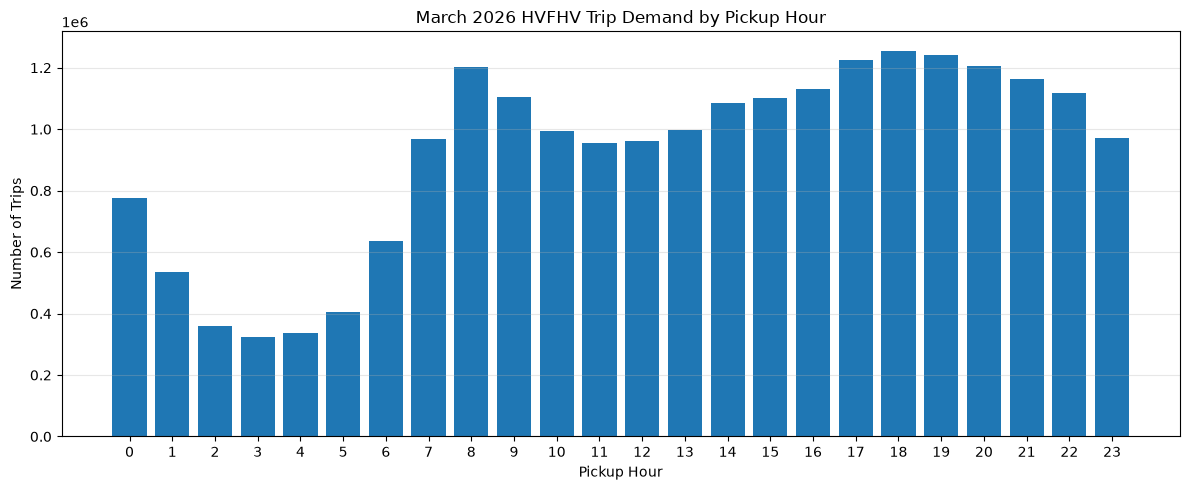

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.bar(
    hourly_demand["pickup_hour"],
    hourly_demand["trip_count"]
)

plt.xlabel("Pickup Hour")
plt.ylabel("Number of Trips")
plt.title("March 2026 HVFHV Trip Demand by Pickup Hour")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 2: Trip Demand by Day of Week

This analysis examines how HVFHV trip demand varies across different days of the week.

Comparing weekday and weekend demand helps identify recurring weekly travel patterns and understand how ride activity changes throughout the week.

In [16]:
# EDA 2: Trip demand by day of week

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

daily_demand = (
    march_analysis
    .groupby("pickup_day_of_week")
    .size()
    .reindex(day_order)
    .reset_index(name="trip_count")
)

peak_day = daily_demand.loc[
    daily_demand["trip_count"].idxmax()
]

lowest_day = daily_demand.loc[
    daily_demand["trip_count"].idxmin()
]

print("Highest demand day:")
print(f"{peak_day['pickup_day_of_week']} ({peak_day['trip_count']:,} trips)")

print("\nLowest demand day:")
print(f"{lowest_day['pickup_day_of_week']} ({lowest_day['trip_count']:,} trips)")

print("\nDaily demand:")
print(daily_demand)

Highest demand day:
Sunday (3,472,487 trips)

Lowest demand day:
Wednesday (2,738,773 trips)

Daily demand:
  pickup_day_of_week  trip_count
0             Monday     3181452
1            Tuesday     3268406
2          Wednesday     2738773
3           Thursday     3015156
4             Friday     3105588
5           Saturday     3276495
6             Sunday     3472487


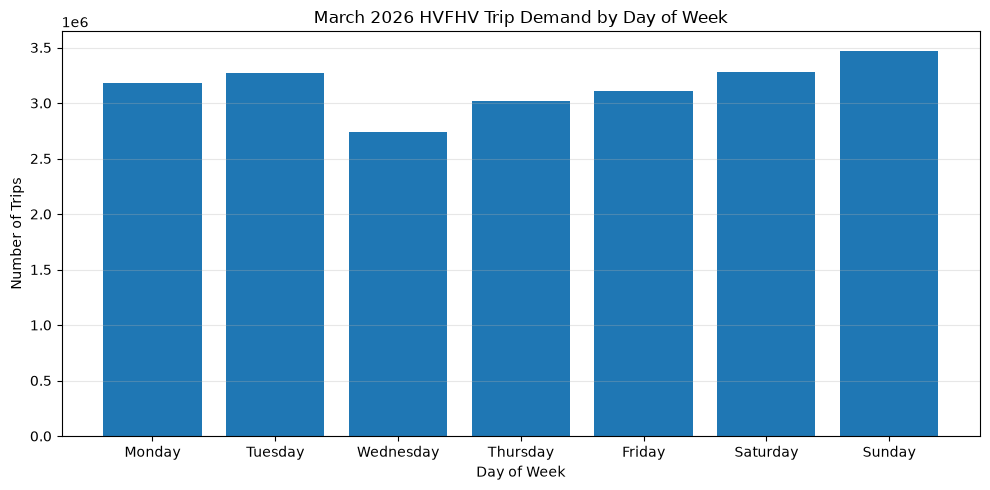

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    daily_demand["pickup_day_of_week"],
    daily_demand["trip_count"]
)

plt.xlabel("Day of Week")
plt.ylabel("Number of Trips")
plt.title("March 2026 HVFHV Trip Demand by Day of Week")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 3: Trip Distance Distribution

This analysis examines the distribution of trip distances across March 2026.

Understanding trip-distance patterns helps identify the typical travel range of HVFHV trips and highlights how frequently short, medium, and long-distance trips occur.

In [18]:
# EDA 3: Trip Distance Distribution

distance_summary = march_analysis["trip_miles"].describe()

print("Trip distance summary:")
print(distance_summary)

Trip distance summary:
count    2.205836e+07
mean     4.799259e+00
std      5.722389e+00
min      0.000000e+00
25%      1.460000e+00
50%      2.800000e+00
75%      5.940000e+00
max      1.644540e+03
Name: trip_miles, dtype: float64


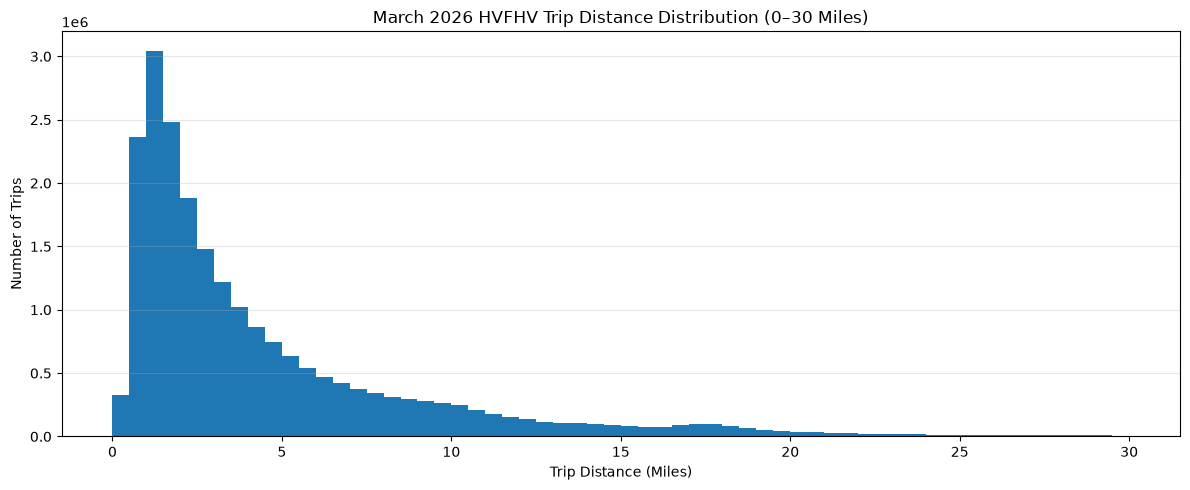

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.hist(
    march_analysis["trip_miles"],
    bins=60,
    range=(0, 30)
)

plt.xlabel("Trip Distance (Miles)")
plt.ylabel("Number of Trips")
plt.title("March 2026 HVFHV Trip Distance Distribution (0–30 Miles)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 4: Trip Duration Distribution

This analysis examines the distribution of trip durations across March 2026.

Understanding trip-duration patterns helps identify the typical length of HVFHV trips and highlights how frequently short, medium, and long-duration trips occur.

In [20]:
# EDA 4: Trip Duration Distribution

duration_summary = march_analysis["trip_duration_minutes"].describe()

print("Trip duration summary (minutes):")
print(duration_summary)

Trip duration summary (minutes):
count    2.205836e+07
mean     1.923976e+01
std      1.383553e+01
min      0.000000e+00
25%      9.583333e+00
50%      1.561667e+01
75%      2.483333e+01
max      6.561167e+02
Name: trip_duration_minutes, dtype: float64


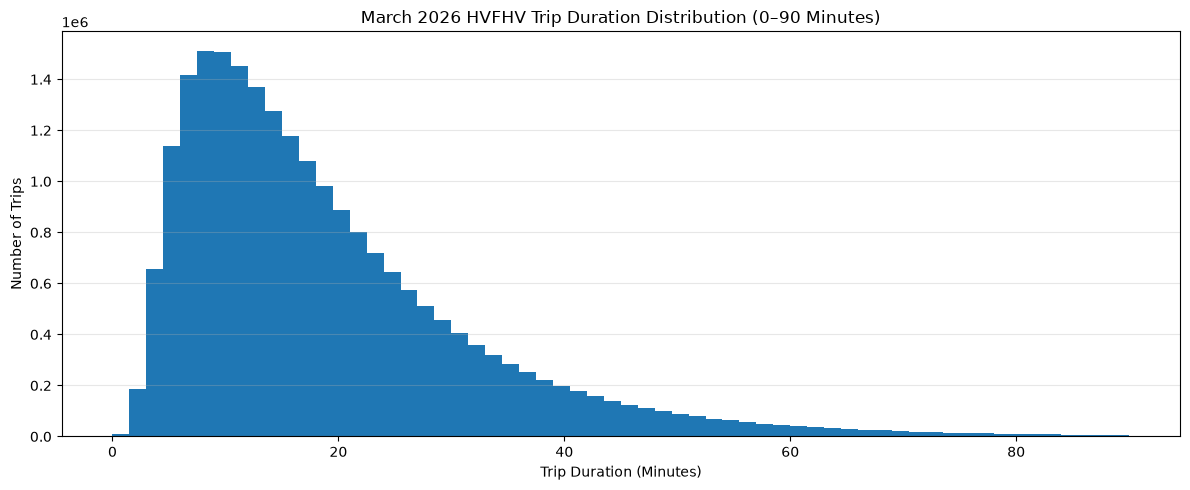

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.hist(
    march_analysis["trip_duration_minutes"],
    bins=60,
    range=(0, 90)
)

plt.xlabel("Trip Duration (Minutes)")
plt.ylabel("Number of Trips")
plt.title("March 2026 HVFHV Trip Duration Distribution (0–90 Minutes)")
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 5: Average Trip Distance by Hour

This analysis examines how average trip distance varies across different pickup hours in March 2026.

Comparing average distance throughout the day helps identify whether travel patterns differ between peak and off-peak periods.

In [22]:
# EDA 5: Average Trip Distance by Hour

avg_distance_by_hour = (
    march_analysis
    .groupby("pickup_hour")["trip_miles"]
    .mean()
    .reset_index(name="avg_trip_miles")
)

print("Average trip distance by pickup hour:")
print(avg_distance_by_hour)

Average trip distance by pickup hour:
    pickup_hour  avg_trip_miles
0             0        5.115822
1             1        5.175888
2             2        5.339262
3             3        6.146359
4             4        6.975614
5             5        6.932070
6             6        5.954072
7             7        4.782595
8             8        4.202832
9             9        4.302851
10           10        4.537168
11           11        4.643731
12           12        4.764490
13           13        4.721099
14           14        4.653979
15           15        4.630317
16           16        4.426804
17           17        4.171834
18           18        4.175377
19           19        4.430635
20           20        4.847836
21           21        5.105469
22           22        5.168931
23           23        5.152021


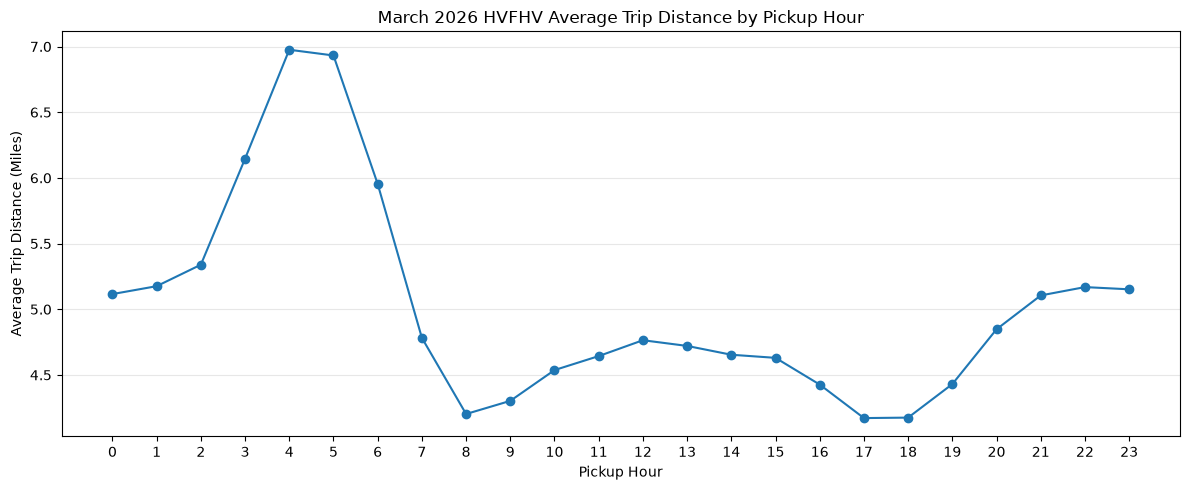

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    avg_distance_by_hour["pickup_hour"],
    avg_distance_by_hour["avg_trip_miles"],
    marker="o"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Average Trip Distance (Miles)")
plt.title("March 2026 HVFHV Average Trip Distance by Pickup Hour")
plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 6: Average Trip Duration by Hour

This analysis examines how average trip duration varies across different pickup hours in March 2026.

Comparing trip duration throughout the day helps identify periods when trips tend to take longer or shorter and provides additional context for understanding daily travel patterns.

In [24]:
# EDA 6: Average Trip Duration by Hour

avg_duration_by_hour = (
    march_analysis
    .groupby("pickup_hour")["trip_duration_minutes"]
    .mean()
    .reset_index(name="avg_trip_duration_minutes")
)

print("Average trip duration by pickup hour:")
print(avg_duration_by_hour)

Average trip duration by pickup hour:
    pickup_hour  avg_trip_duration_minutes
0             0                  17.243077
1             1                  16.685021
2             2                  16.558436
3             3                  17.358926
4             4                  18.241873
5             5                  18.887932
6             6                  19.156302
7             7                  19.383574
8             8                  18.690100
9             9                  18.437088
10           10                  18.847928
11           11                  19.516890
12           12                  20.061900
13           13                  20.516905
14           14                  21.659607
15           15                  22.563208
16           16                  22.292057
17           17                  20.755394
18           18                  18.959639
19           19                  18.018867
20           20                  18.021891
21           21 

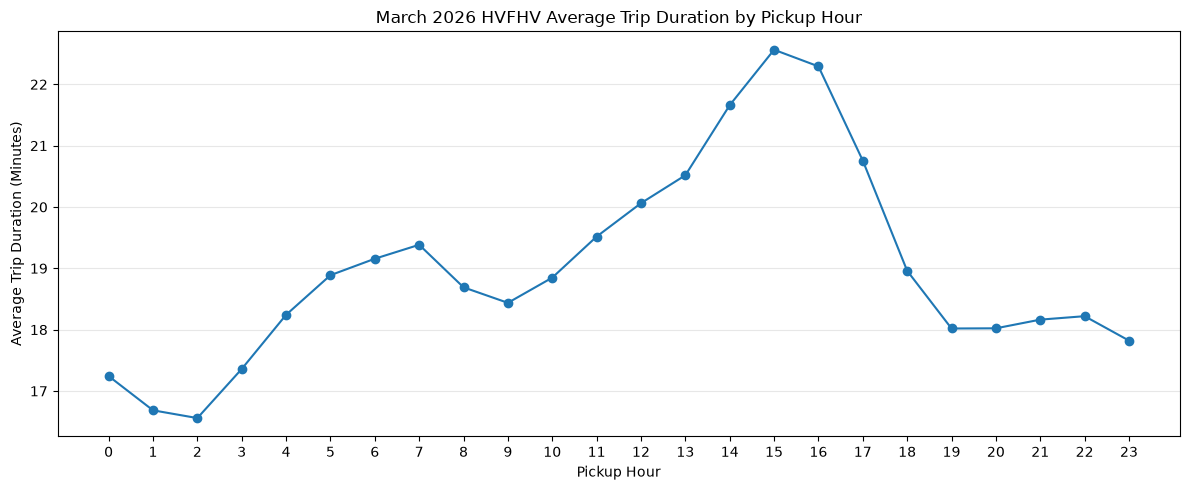

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    avg_duration_by_hour["pickup_hour"],
    avg_duration_by_hour["avg_trip_duration_minutes"],
    marker="o"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Average Trip Duration (Minutes)")
plt.title("March 2026 HVFHV Average Trip Duration by Pickup Hour")

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 7: Average Trip Distance by Day of Week

This analysis examines how the average trip distance varies across different days of the week in March 2026.

Comparing average trip distance by day helps identify differences in travel patterns between weekdays and weekends and provides additional context about how trip characteristics change throughout the week.

In [26]:
# EDA 7: Average Trip Distance by Day of Week

avg_distance_by_day = (
    march_analysis
    .groupby("pickup_day_of_week")["trip_miles"]
    .mean()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index(name="avg_trip_miles")
)

highest_distance_day = avg_distance_by_day.loc[
    avg_distance_by_day["avg_trip_miles"].idxmax()
]

lowest_distance_day = avg_distance_by_day.loc[
    avg_distance_by_day["avg_trip_miles"].idxmin()
]

print("Highest average trip distance day:")
print(
    f"{highest_distance_day['pickup_day_of_week']} "
    f"({highest_distance_day['avg_trip_miles']:.2f} miles)"
)

print("\nLowest average trip distance day:")
print(
    f"{lowest_distance_day['pickup_day_of_week']} "
    f"({lowest_distance_day['avg_trip_miles']:.2f} miles)"
)

print("\nAverage trip distance by day:")
print(avg_distance_by_day)

Highest average trip distance day:
Sunday (5.17 miles)

Lowest average trip distance day:
Tuesday (4.66 miles)

Average trip distance by day:
  pickup_day_of_week  avg_trip_miles
0             Monday        4.746748
1            Tuesday        4.658667
2          Wednesday        4.801642
3           Thursday        4.763308
4             Friday        4.704160
5           Saturday        4.719506
6             Sunday        5.169338


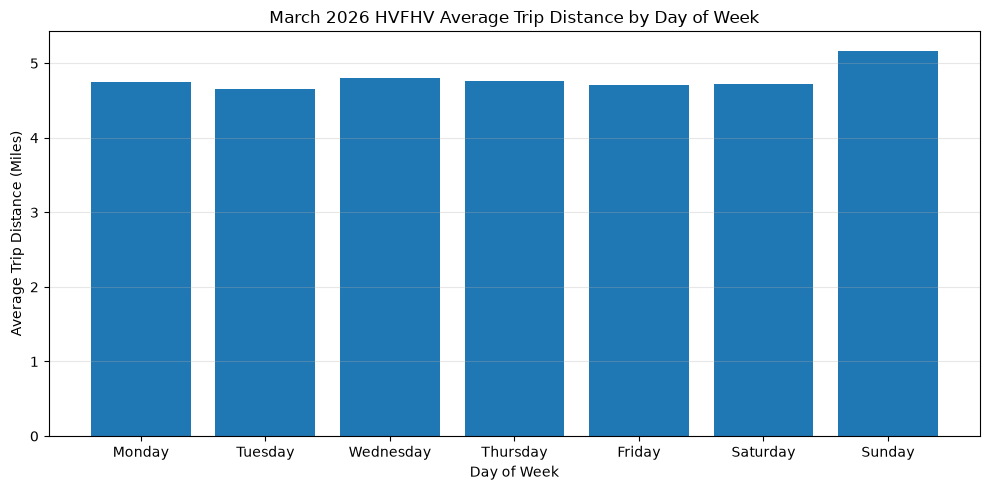

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    avg_distance_by_day["pickup_day_of_week"],
    avg_distance_by_day["avg_trip_miles"]
)

plt.xlabel("Day of Week")
plt.ylabel("Average Trip Distance (Miles)")
plt.title("March 2026 HVFHV Average Trip Distance by Day of Week")

plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 8: Trip Count by Service Provider

This analysis examines how trip volume is distributed across the different HVFHS service providers in March 2026.

Comparing trip counts by provider helps understand the relative share of ride activity handled by each service provider and provides context for the competitive structure of the HVFHV market.

In [28]:
# EDA 8: Trip Count by Service Provider

provider_demand = (
    march_analysis
    .groupby("hvfhs_license_num")
    .size()
    .reset_index(name="trip_count")
    .sort_values("trip_count", ascending=False)
)

print("Trip count by service provider:")
print(provider_demand)

print("\nProvider share of total trips:")
provider_demand["trip_share_pct"] = (
    provider_demand["trip_count"]
    / provider_demand["trip_count"].sum()
    * 100
)

print(provider_demand)

Trip count by service provider:
  hvfhs_license_num  trip_count
0            HV0003    15956174
1            HV0005     6102183

Provider share of total trips:
  hvfhs_license_num  trip_count  trip_share_pct
0            HV0003    15956174       72.336185
1            HV0005     6102183       27.663815


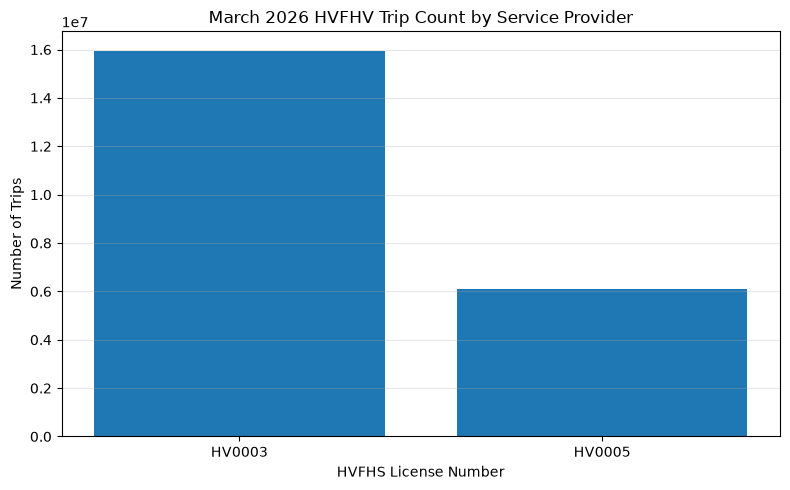

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    provider_demand["hvfhs_license_num"],
    provider_demand["trip_count"]
)

plt.xlabel("HVFHS License Number")
plt.ylabel("Number of Trips")
plt.title("March 2026 HVFHV Trip Count by Service Provider")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 9: Average Trip Distance by Service Provider

This analysis examines how average trip distance varies across HVFHS service providers in March 2026.

Comparing trip distance across providers helps identify differences in the types of trips served and provides additional context for understanding provider-level operating patterns.

In [30]:
# EDA 9: Average Trip Distance by Service Provider

provider_distance = (
    march_analysis
    .groupby("hvfhs_license_num")["trip_miles"]
    .mean()
    .reset_index(name="avg_trip_miles")
    .sort_values("avg_trip_miles", ascending=False)
)

highest_provider_distance = provider_distance.iloc[0]
lowest_provider_distance = provider_distance.iloc[-1]

print("Highest average trip distance:")
print(
    f"{highest_provider_distance['hvfhs_license_num']} "
    f"({highest_provider_distance['avg_trip_miles']:.2f} miles)"
)

print("\nLowest average trip distance:")
print(
    f"{lowest_provider_distance['hvfhs_license_num']} "
    f"({lowest_provider_distance['avg_trip_miles']:.2f} miles)"
)

print("\nAverage trip distance by service provider:")
print(provider_distance)

Highest average trip distance:
HV0003 (4.91 miles)

Lowest average trip distance:
HV0005 (4.51 miles)

Average trip distance by service provider:
  hvfhs_license_num  avg_trip_miles
0            HV0003        4.910990
1            HV0005        4.507102


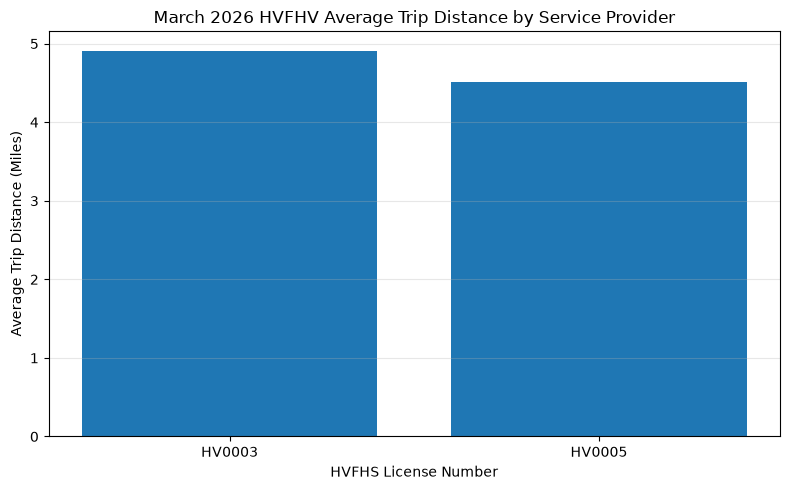

In [31]:
# EDA 9: Average Trip Distance by Service Provider - Visualization

plt.figure(figsize=(8, 5))

plt.bar(
    provider_distance["hvfhs_license_num"],
    provider_distance["avg_trip_miles"]
)

plt.xlabel("HVFHS License Number")
plt.ylabel("Average Trip Distance (Miles)")
plt.title("March 2026 HVFHV Average Trip Distance by Service Provider")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 10: Average Trip Duration by Service Provider

This analysis examines how average trip duration varies across HVFHS service providers in March 2026.

Comparing trip duration across providers helps identify differences in the typical time spent on trips and provides additional context about provider-level operating patterns.

In [32]:
# EDA 10: Average Trip Duration by Service Provider

provider_duration = (
    march_analysis
    .groupby("hvfhs_license_num")["trip_duration_minutes"]
    .mean()
    .reset_index(name="avg_trip_duration_minutes")
    .sort_values("avg_trip_duration_minutes", ascending=False)
)

highest_provider_duration = provider_duration.iloc[0]
lowest_provider_duration = provider_duration.iloc[-1]

print("Highest average trip duration:")
print(
    f"{highest_provider_duration['hvfhs_license_num']} "
    f"({highest_provider_duration['avg_trip_duration_minutes']:.2f} minutes)"
)

print("\nLowest average trip duration:")
print(
    f"{lowest_provider_duration['hvfhs_license_num']} "
    f"({lowest_provider_duration['avg_trip_duration_minutes']:.2f} minutes)"
)

print("\nAverage trip duration by service provider:")
print(provider_duration)

Highest average trip duration:
HV0003 (19.41 minutes)

Lowest average trip duration:
HV0005 (18.79 minutes)

Average trip duration by service provider:
  hvfhs_license_num  avg_trip_duration_minutes
0            HV0003                  19.412765
1            HV0005                  18.787391


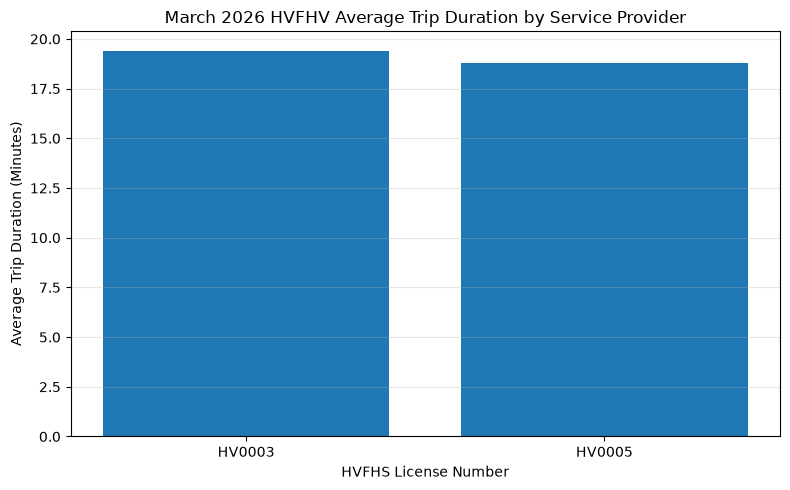

In [33]:
# EDA 10: Average Trip Duration by Service Provider - Visualization

plt.figure(figsize=(8, 5))

plt.bar(
    provider_duration["hvfhs_license_num"],
    provider_duration["avg_trip_duration_minutes"]
)

plt.xlabel("HVFHS License Number")
plt.ylabel("Average Trip Duration (Minutes)")
plt.title("March 2026 HVFHV Average Trip Duration by Service Provider")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

## EDA 11: Trip Demand by Day and Hour

This analysis examines how HVFHV trip demand varies across different days of the week and hours of the day in March 2026.

Analyzing demand across both dimensions helps identify recurring time periods with higher or lower ride activity throughout the week.

In [34]:
# EDA 11: Trip Demand by Day and Hour

day_hour_demand = (
    march_analysis
    .groupby(["pickup_day_of_week", "pickup_hour"])
    .size()
    .reset_index(name="trip_count")
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_hour_demand["pickup_day_of_week"] = pd.Categorical(
    day_hour_demand["pickup_day_of_week"],
    categories=day_order,
    ordered=True
)

day_hour_demand = day_hour_demand.sort_values(
    ["pickup_day_of_week", "pickup_hour"]
)

print("Trip demand by day and hour:")
print(day_hour_demand)

Trip demand by day and hour:
   pickup_day_of_week  pickup_hour  trip_count
24             Monday            0       84624
25             Monday            1       50514
26             Monday            2       35445
27             Monday            3       31445
28             Monday            4       42763
..                ...          ...         ...
91             Sunday           19      168997
92             Sunday           20      168579
93             Sunday           21      161591
94             Sunday           22      149341
95             Sunday           23      126269

[168 rows x 3 columns]


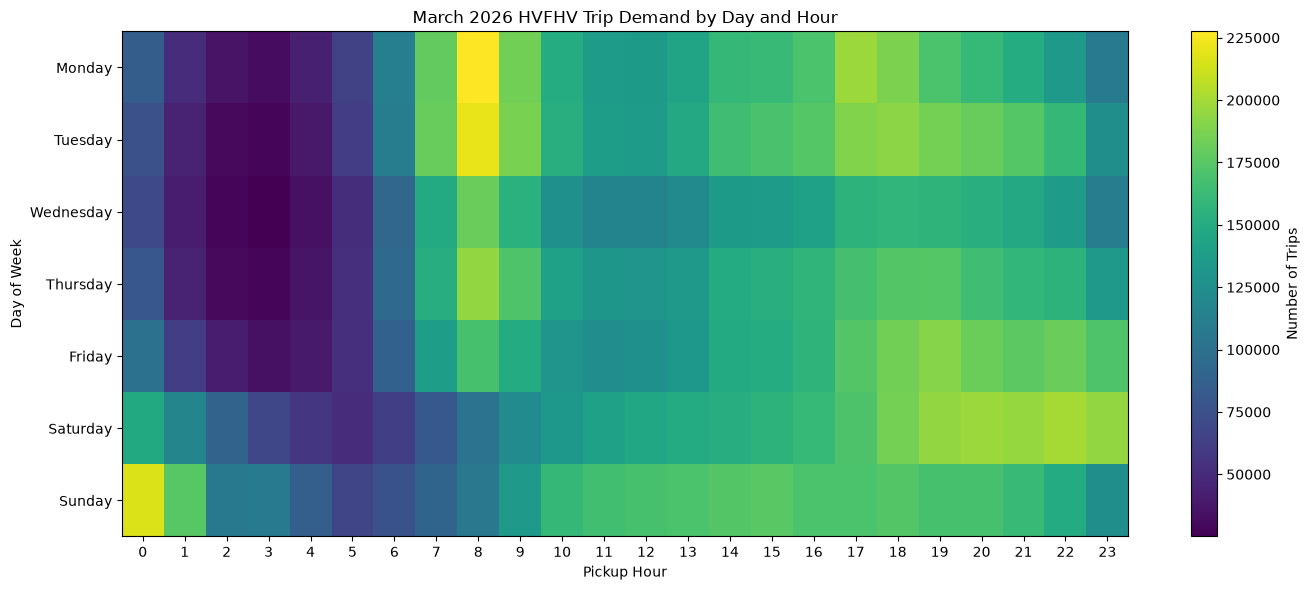

In [35]:
# EDA 11: Trip Demand by Day and Hour - Visualization

demand_heatmap = day_hour_demand.pivot(
    index="pickup_day_of_week",
    columns="pickup_hour",
    values="trip_count"
)

plt.figure(figsize=(14, 6))

plt.imshow(
    demand_heatmap,
    aspect="auto",
    interpolation="nearest"
)

plt.colorbar(label="Number of Trips")

plt.xticks(range(24), range(24))
plt.yticks(
    range(len(day_order)),
    day_order
)

plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")
plt.title("March 2026 HVFHV Trip Demand by Day and Hour")

plt.tight_layout()
plt.show()

## EDA 12: Average Trip Distance by Hour and Day

This analysis examines how average trip distance varies across different hours of the day and days of the week in March 2026.

Analyzing trip distance across both dimensions helps identify time periods when trips tend to be shorter or longer.

In [36]:
# EDA 12: Average Trip Distance by Hour and Day

distance_day_hour = (
    march_analysis
    .groupby(["pickup_day_of_week", "pickup_hour"])["trip_miles"]
    .mean()
    .reset_index(name="avg_trip_miles")
)

distance_day_hour["pickup_day_of_week"] = pd.Categorical(
    distance_day_hour["pickup_day_of_week"],
    categories=day_order,
    ordered=True
)

distance_day_hour = distance_day_hour.sort_values(
    ["pickup_day_of_week", "pickup_hour"]
)

print("Average trip distance by day and hour:")
print(distance_day_hour)

Average trip distance by day and hour:
   pickup_day_of_week  pickup_hour  avg_trip_miles
24             Monday            0        5.492428
25             Monday            1        5.744293
26             Monday            2        5.688335
27             Monday            3        6.683197
28             Monday            4        7.408563
..                ...          ...             ...
91             Sunday           19        4.838883
92             Sunday           20        4.908143
93             Sunday           21        5.099513
94             Sunday           22        5.250686
95             Sunday           23        5.358987

[168 rows x 3 columns]


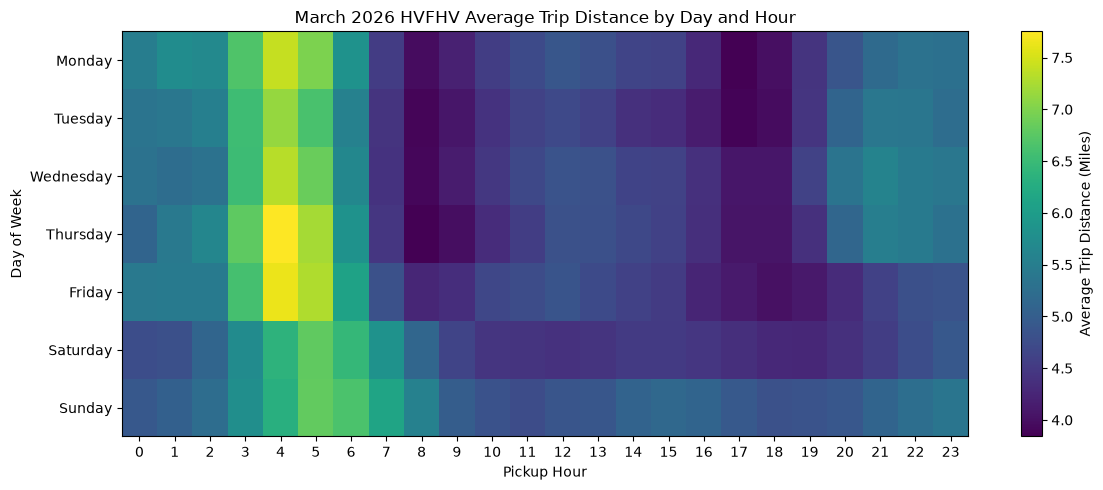

In [37]:
# EDA 12: Visualization

distance_pivot = distance_day_hour.pivot(
    index="pickup_day_of_week",
    columns="pickup_hour",
    values="avg_trip_miles"
)

distance_pivot = distance_pivot.reindex(day_order)

plt.figure(figsize=(12, 5))

plt.imshow(
    distance_pivot,
    aspect="auto",
    cmap="viridis"
)

plt.colorbar(label="Average Trip Distance (Miles)")

plt.xticks(range(24), range(24))
plt.yticks(range(len(day_order)), day_order)

plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")
plt.title("March 2026 HVFHV Average Trip Distance by Day and Hour")

plt.tight_layout()
plt.show()

# EDA 13: Total Passenger Charges by Service Provider

This analysis examines the total passenger charges associated with each HVFHS service provider in March 2026.

Comparing passenger charges across service providers helps understand the overall monetary volume generated by trips and provides additional context for provider-level performance.

In [38]:
# EDA 13: Total Passenger Charges by Service Provider

march_analysis["total_passenger_charges"] = (
    march_analysis["base_passenger_fare"]
    + march_analysis["tolls"]
    + march_analysis["sales_tax"]
    + march_analysis["congestion_surcharge"]
    + march_analysis["airport_fee"]
    + march_analysis["cbd_congestion_fee"]
    + march_analysis["tips"]
)

provider_charges = (
    march_analysis
    .groupby("hvfhs_license_num")["total_passenger_charges"]
    .sum()
    .reset_index(name="total_charges")
    .sort_values("total_charges", ascending=False)
)

print("Total passenger charges by service provider:")
print(provider_charges)

Total passenger charges by service provider:
  hvfhs_license_num  total_charges
0            HV0003   5.492419e+08
1            HV0005   1.969716e+08


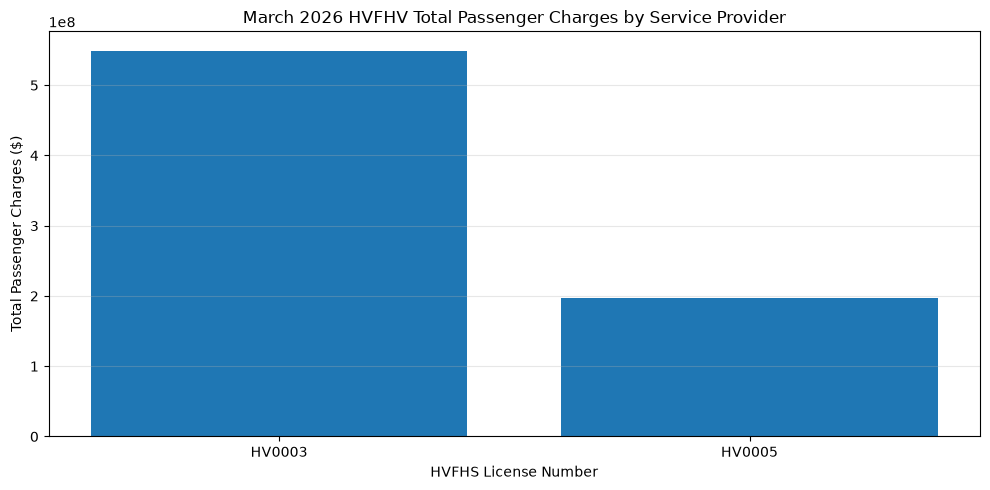

In [39]:
# EDA 13: Visualization

plt.figure(figsize=(10, 5))

plt.bar(
    provider_charges["hvfhs_license_num"],
    provider_charges["total_charges"]
)

plt.xlabel("HVFHS License Number")
plt.ylabel("Total Passenger Charges ($)")
plt.title("March 2026 HVFHV Total Passenger Charges by Service Provider")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# EDA 14: Average Passenger Fare by Service Provider

This analysis examines the average base passenger fare across HVFHS service providers in March 2026.

Comparing average fares helps identify differences in typical passenger charges between providers and provides additional context when interpreting provider-level trip volume and trip characteristics.

In [40]:
# EDA 14: Average Passenger Fare by Service Provider

provider_fare = (
    march_analysis
    .groupby("hvfhs_license_num")["base_passenger_fare"]
    .mean()
    .reset_index(name="avg_base_fare")
    .sort_values("avg_base_fare", ascending=False)
)

highest_provider_fare = provider_fare.iloc[0]
lowest_provider_fare = provider_fare.iloc[-1]

print("Highest average passenger fare:")
print(
    f"{highest_provider_fare['hvfhs_license_num']} "
    f"(${highest_provider_fare['avg_base_fare']:.2f})"
)

print("\nLowest average passenger fare:")
print(
    f"{lowest_provider_fare['hvfhs_license_num']} "
    f"(${lowest_provider_fare['avg_base_fare']:.2f})"
)

print("\nAverage passenger fare by service provider:")
print(provider_fare)

Highest average passenger fare:
HV0003 ($28.08)

Lowest average passenger fare:
HV0005 ($26.36)

Average passenger fare by service provider:
  hvfhs_license_num  avg_base_fare
0            HV0003      28.076728
1            HV0005      26.362612


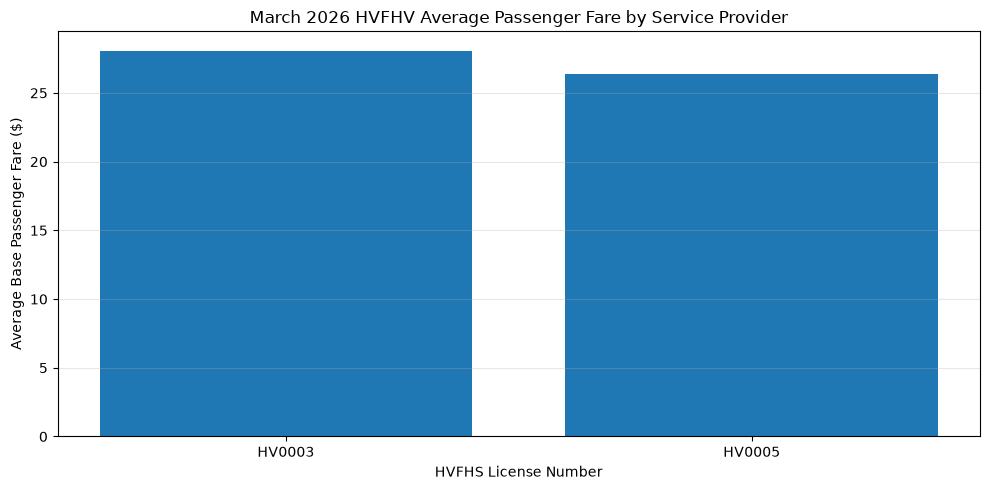

In [41]:
# EDA 14: Visualization

plt.figure(figsize=(10, 5))

plt.bar(
    provider_fare["hvfhs_license_num"],
    provider_fare["avg_base_fare"]
)

plt.xlabel("HVFHS License Number")
plt.ylabel("Average Base Passenger Fare ($)")
plt.title("March 2026 HVFHV Average Passenger Fare by Service Provider")

plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

# EDA 15: Average Tips by Pickup Hour

This analysis examines how average tip amounts vary across different pickup hours in March 2026.

Understanding tipping patterns throughout the day provides additional insight into passenger behavior and helps identify time periods associated with higher or lower average tips.

In [42]:
# EDA 15: Average Tips by Pickup Hour

avg_tips_by_hour = (
    march_analysis
    .groupby("pickup_hour")["tips"]
    .mean()
    .reset_index(name="avg_tips")
)

highest_tip_hour = avg_tips_by_hour.loc[
    avg_tips_by_hour["avg_tips"].idxmax()
]

lowest_tip_hour = avg_tips_by_hour.loc[
    avg_tips_by_hour["avg_tips"].idxmin()
]

print("Highest average tip hour:")
print(
    f"{int(highest_tip_hour['pickup_hour']):02d}:00 "
    f"(${highest_tip_hour['avg_tips']:.2f})"
)

print("\nLowest average tip hour:")
print(
    f"{int(lowest_tip_hour['pickup_hour']):02d}:00 "
    f"(${lowest_tip_hour['avg_tips']:.2f})"
)

print("\nAverage tips by pickup hour:")
print(avg_tips_by_hour)

Highest average tip hour:
05:00 ($1.53)

Lowest average tip hour:
02:00 ($0.86)

Average tips by pickup hour:
    pickup_hour  avg_tips
0             0  0.997459
1             1  0.912606
2             2  0.858543
3             3  1.054267
4             4  1.466717
5             5  1.532118
6             6  1.256211
7             7  1.119348
8             8  1.077298
9             9  1.151076
10           10  1.258098
11           11  1.343402
12           12  1.395756
13           13  1.350205
14           14  1.334556
15           15  1.364413
16           16  1.307772
17           17  1.246842
18           18  1.210881
19           19  1.152035
20           20  1.222028
21           21  1.323059
22           22  1.226037
23           23  1.075981


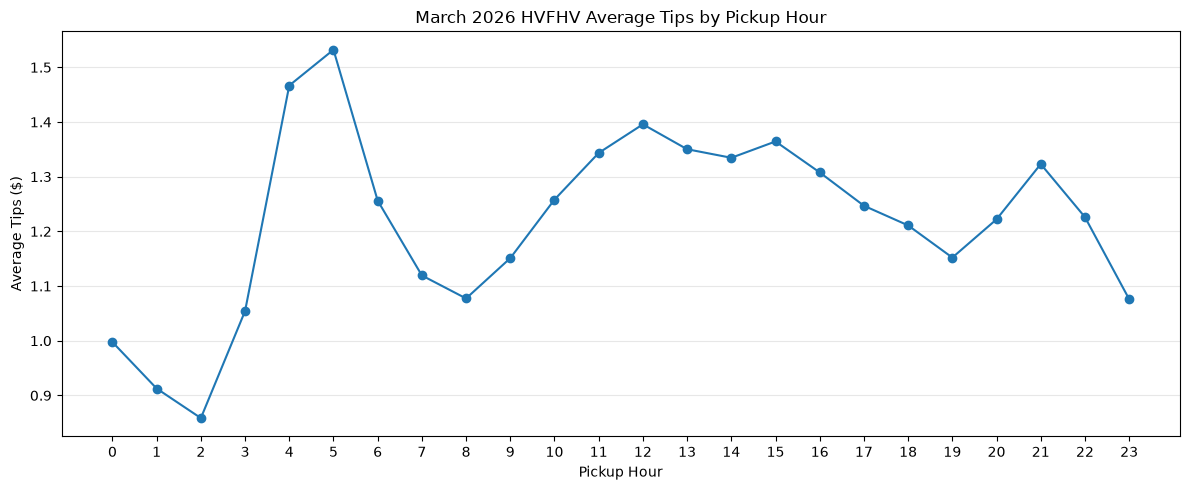

In [43]:
# EDA 15: Visualization

plt.figure(figsize=(12, 5))

plt.plot(
    avg_tips_by_hour["pickup_hour"],
    avg_tips_by_hour["avg_tips"],
    marker="o"
)

plt.xlabel("Pickup Hour")
plt.ylabel("Average Tips ($)")
plt.title("March 2026 HVFHV Average Tips by Pickup Hour")

plt.xticks(range(24))
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()